---
>「第一の原則は、自分自身を欺いてはならないということである そして、最も欺きやすい相手は自分自身である」
>
> リチャード・ファインマン（1974年、カリフォルニア工科大学の卒業式での講演）

---

# モデル構築と評価

- ここまでscikit-learn による機械学習を扱った
  - 以降、深層学習（DNN）に繋がる話に入る
  - ニューラルネットワークの構造と学習を学び、以降のテキストで PyTorch を使って実際に学習させる
  - 深層学習に入る前に、**一般的に成り立つ原則**を確かめる

「DNN入門」という題であるがここでは scikit-learn を扱う
- ここで扱うのはライブラリの使い方ではなく、どのライブラリでも、どのモデルでも成り立つ原則である
- 実演に scikit-learn を使うのは、短いコードと数秒の計算で、原則が破れたときに何が起こるかを確かめられるため
- ここで確かめた原則は、深層学習でそのまま使う

なぜ、基本原則が重要なのか？
- 深層学習では、モデルは大きくなり、学習には時間がかかり、データは表から画像、音声、文章に変わる
- 「作ったモデルが未知のデータでどれだけ当たるかを、正しく見積もる」という課題は変わらない
- スコアは高いのに運用すると当たらない、という失敗の原因の多くは、アルゴリズムではなく**データの分け方と評価の手順**にある
- 手順の誤りはエラーにならないため、大きなモデルで何時間も学習した後では、気づくのがさらに難しくなる

ここでは以下を扱う

1. **評価を汚さない**: データリーク、すなわち評価用データの情報が学習に漏れること
2. **分割の設計**: 時間、人、文書など、運用時に新しくなる単位で分けること
3. **不均衡データと評価指標**: 正解率が役に立たない場面と、目的に合う指標の選び方
4. **確率の校正**: モデルの出力する確率を、数値として信用してよいかの確かめ方
5. **費用を考慮したしきい値の決定**: 誤りの費用から、判定の線引きを決めること
6. **特徴選択と重要度**: 入力を絞ることと、モデルが何を使っているかの確かめ方
7. **まとめ（点検表）**: 後編以降でモデルを学習させるたびに確かめる項目

---

# この講義でできるようになること

- データリークが起こる経路（前処理、目的変数から作る特徴量、候補の選び方、分割）を挙げ、それぞれを実験で再現し、防ぐ手順を組めるようになる
- 運用時に何が新しくなるかから、分割の単位（時間、グループ）を決められるようになる
- 不均衡データで、正解率に代えて適合率、再現率、PR曲線、APを用いて評価できるようになる
- 予測確率が校正されているかを信頼性曲線で確かめ、必要なら補正できるようになる
- 見逃しと誤検出の費用から、しきい値を決められるようになる
- 特徴量の重要度を、その偏りを理解したうえで読めるようになる
- 以上の原則が、深層学習や大規模言語モデル（LLM）ではどのような形で現れるかを説明できるようになる

---

# 全体像

モデルを作る作業は、どのライブラリを使っても、おおよそ次の5段階で進む

1. データを分割する
2. 前処理を行い、特徴量を作る
3. 学習し、候補（モデルの種類、ハイパーパラメータ）の中から選ぶ
4. 評価する
5. 判定の基準を決めて運用する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/mlprac-overview.png" width=760>

上の図は、この5段階（上段）と、各段階で守る原則（下段、本テキストの節の題）の対応を示している
- どの段階にも、気づかないうちに評価を甘くしてしまう落とし穴がある
- 落とし穴に落ちてもエラーは出ず、スコアはむしろ良くなるため、手順として防ぐしかない

## 各節の進め方

各節は、次の4つの順で進める

1. **原則**: ライブラリに依存しない形で、何を守るのかを述べる
2. **scikit-learn による実演**: 原則を破った場合と守った場合を、小さなデータで比べる
3. **結果の読み方**: 数値がなぜそうなったのかを説明する
4. **深層学習や LLM ではどう現れるか**: 同じ原則が、後編以降のテキストでどのような形を取るかを述べる

4がこれ以降の橋渡しになるが、ここで用いられる用語（バッチ正規化、トークナイザ、早期終了など）のうち未習のものは、いまは名前だけを覚えておけばよい
- 該当するテキストに進んだときに、この節へ戻って読み直すとよい

なお、本テキストは次の章の内容を前提とし、そこで説明済みの内容は繰り返さない

| 話題 | 参照先 |
| --- | --- |
| 混同行列、正解率、適合率、再現率、F値、ROC曲線、過学習 | `mlsys-text-2-ML基礎.ipynb` |
| 欠損値の補完 | `mlsys-text-3-データの扱い.ipynb` |
| scikit-learn の基本操作、データセットの分割、スケーリング、SVM、決定木、ランダムフォレスト | `mlsys-text-4-MLライブラリの基礎.ipynb` |
| scikit-learn の各モデルの俯瞰（`MLPClassifier` を含む） | `mlsys-text-5-Sklearn-まとめ.ipynb` |

本テキストの原則は、次の章でそのまま使う

| 話題 | 参照先 |
| --- | --- |
| ニューラルネットワークの構造と学習 | `mlsys-text-6-DNN入門-2-ニューラルネットワーク.ipynb`（後編） |
| PyTorch での学習と評価、`model.eval()` | `mlsys-text-7-PyTorch.ipynb`、`mlsys-text-8-PyTorch-Basics.ipynb` |
| 同じ録音から切り出した音の分割、異常検知のしきい値 | `mlsys-text-G-音声処理-2-異常音検知.ipynb` |
| LLMの評価、評価データの汚染、評価セットへの過適合 | `mlsys-text-M-LLM-4-評価.ipynb` |
| 集団ごとの校正としきい値、入出力の検査の見逃し率と誤検知率 | `mlsys-text-T-安全性と公平性.ipynb` |

## 準備

本テキストのコードは scikit-learn、NumPy、SciPy、pandas、matplotlib だけを使い、GPUは不要である
- どのコードセルも、CPUで数秒から十数秒で終わる
- `TargetEncoder` を使うため、scikit-learn 1.3以降が必要である
  - scikit-learn 1.9以降では、`TargetEncoder` の `random_state` 引数について、将来の変更を知らせる警告（FutureWarning）が表示されるが、結果には影響しない

In [ ]:
# scikit-learnのバージョンを確認する
import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.6.1


---

# 評価を汚さない：データリーク

**データリーク（Data Leakage）**とは、本来は学習時に知ることのできない評価用データの情報が、学習に入り込んでしまうこと
- データリークが起きると、実際には性能が低いのに、評価値だけ非常に良く見えるという問題が起こる
- しかも、プログラム上のエラーにはならないことが多いため注意が必要

## 原則

テストデータは、**本番で出会う未知のデータの代役**である
- 代役が務まるのは、モデルを作る過程のどこにも、そのデータの情報が入っていない場合に限る
- 評価用のデータの情報が、何らかの経路で学習の側に漏れることを**データリーク（data leakage）**と呼ぶ
- 漏れがあると、スコアは実力より良く出る
  - エラーにも警告にもならず、結果は「うまくいった」ようにしか見えない

漏れる経路は、大きく4つある
- **前処理**: 平均と分散、欠損値の補完値、語彙、選ぶ列などを、評価用のデータも含めて求めてしまう
- **目的変数から作る特徴量**: その標本自身の正解が、特徴量の中に入ってしまう
- **候補の選び方**: ハイパーパラメータや学習を止める時点を、テストデータの成績を見て選んでしまう
- **分割**: 訓練側と評価側に、互いによく似た標本（同じ人、隣り合う日）が入ってしまう

この節では最初の3つを、次の節「分割の設計」で4つ目を扱う

守るべきことは、次の1文にまとめられる
- **データから値を決める操作は、すべて訓練データだけで行い、評価用のデータにはその結果を適用するだけにする**

## 前処理は訓練データだけから作る

平均と分散は訓練データだけから求める
- ホールドアウト法では `scaler.fit(X_train)` と書けば守れる
- 交差検証では、訓練側と検証側が fold ごとに入れ替わるため、手で書くと守りにくい

ただし、よくある誤りは、次の順序である
1. 全データで前処理を `fit_transform` する
2. その結果を `cross_val_score` や `GridSearchCV` に渡す

この順序では、各 fold の検証側のデータが、前処理の `fit` にすでに使われている
- 検証側は「未知のデータ」の代役であるのに、その情報が訓練に漏れている

原則を守るための道具が `Pipeline` である
- `Pipeline` は、前処理とモデルを1つの推定器にまとめる
- `Pipeline` に対して `fit` を呼ぶと、前処理の `fit` も同じ訓練データだけで行われる
- `cross_val_score` に `Pipeline` を渡せば、fold ごとに前処理から学習し直すため、漏れが起こらない
- たとえば、SVMのグリッドサーチで用いた `make_pipeline(StandardScaler(), SVC())` は、この目的で使っていた
  - `make_pipeline` は各段の名前を自動で付ける `Pipeline` の短縮形である
  - `svc__C` のように「段の名前 + `__` + 引数名」でハイパーパラメータを指定できる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-leak-cv.png" width=700>

上の図は、2つの手順の違いを示している
- 上段では、fold に分ける前に前処理の `fit` が済んでおり、検証側になる標本もその計算に含まれている
- 下段では、fold に分けた後に訓練側だけで `fit` し、検証側には訓練側で求めた値を使って `transform` だけを行う

では、漏れによってスコアがどれだけ変わるのかを実験で確かめる
- 実験A: スケーリングを交差検証の外で行う場合と、`Pipeline` に入れる場合を比べる
- 実験B: 正解ラベルを使う前処理（特徴選択）で同じ比較を行う
  - 特徴量もラベルも乱数で作るため、どう頑張っても正解率は0.5にしかならないはずである

In [ ]:
# 前処理を交差検証の外で行う場合と、Pipelineに入れる場合のスコアを比べる
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC

# 実験A: スケーリング（ラベルを使わない前処理）
# 60件だけを手元のデータとし、残り2000件を「本番で出会う未知のデータ」とみなす
n_small = 60
res_a = []
for seed in range(30):
    X_all, y_all = make_classification(n_samples=n_small + 2000, n_features=10,
                                       n_informative=4, random_state=seed)
    X_s, y_s = X_all[:n_small], y_all[:n_small]
    X_new, y_new = X_all[n_small:], y_all[n_small:]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # 誤り: 全データでスケーリングしてから交差検証
    outside = cross_val_score(SVC(), StandardScaler().fit_transform(X_s), y_s, cv=cv).mean()
    # 正しい: スケーリングをPipelineに入れて交差検証
    inside = cross_val_score(make_pipeline(StandardScaler(), SVC()), X_s, y_s, cv=cv).mean()
    # 実力: 未知のデータでの正解率
    real = make_pipeline(StandardScaler(), SVC()).fit(X_s, y_s).score(X_new, y_new)
    res_a.append((outside, inside, real))
res_a = np.array(res_a)
print("実験A スケーリング（30回の平均）")
print("  交差検証の外でfit : %.3f" % res_a[:, 0].mean())
print("  Pipelineの中でfit : %.3f" % res_a[:, 1].mean())
print("  未知データでの実力: %.3f" % res_a[:, 2].mean())
print("  外と中の差の標準偏差: %.3f" % (res_a[:, 0] - res_a[:, 1]).std())

# 実験B: 特徴選択（ラベルを使う前処理）
# 特徴量もラベルも乱数であり、予測できる関係は存在しない
res_b = []
for seed in range(30):
    rng = np.random.default_rng(seed)
    X_r = rng.normal(size=(100, 2000))
    y_r = rng.integers(0, 2, size=100)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # 誤り: 全データで「ラベルと関係が強い20列」を選んでから交差検証
    X_sel = SelectKBest(f_classif, k=20).fit_transform(X_r, y_r)
    outside = cross_val_score(SVC(), X_sel, y_r, cv=cv).mean()
    # 正しい: 特徴選択もPipelineに入れる
    pipe = make_pipeline(SelectKBest(f_classif, k=20), SVC())
    inside = cross_val_score(pipe, X_r, y_r, cv=cv).mean()
    res_b.append((outside, inside))
res_b = np.array(res_b)
print("実験B 特徴選択（30回の平均、真の正解率は0.5）")
print("  交差検証の外でfit : %.3f" % res_b[:, 0].mean())
print("  Pipelineの中でfit : %.3f" % res_b[:, 1].mean())

実験A スケーリング（30回の平均）
  交差検証の外でfit : 0.803
  Pipelineの中でfit : 0.799
  未知データでの実力: 0.805
  外と中の差の標準偏差: 0.017
実験B 特徴選択（30回の平均、真の正解率は0.5）
  交差検証の外でfit : 0.861
  Pipelineの中でfit : 0.523


### 結果の読み方

2つの実験で、結果の様子がまったく異なる点に注目する

ここで、
- 外とは、交差検証を始める前に全データで前処理、つまり、全100件で前処理を決める→その後で5分割交差検証
- 中とは、各foldの訓練データだけで前処理、つまり、5分割する→各回の80件だけで前処理を決める→残り20件に適用して評価

外はダメな手法である

実験A（スケーリング）では、外で行っても中で行っても、平均のスコアはほとんど変わらない
- 差は、乱数の種を変えたときのばらつきに埋もれる大きさである
- スケーリングが使うのは特徴量の平均と分散だけであり、検証側の数件が加わっても値がわずかに動くだけである
- 「スケーリングを外で行うと必ずスコアが大きく水増しされる」わけではない
- だからといって、許されるわけではない

実験B（特徴選択）では、外で行うと、乱数しかないデータで0.8を超える正解率が出る
- 2000列もあれば、100件のラベルと**偶然**相関する列がいくつも見つかる
- 全データでその列を選ぶと、検証側のラベルに合う列を先に選んだことになる
- `Pipeline` に入れた場合は、ほぼ0.5という正しい値になる

つまり、漏れの大きさは「前処理が検証側の何を見るか」で決まる
- 正解ラベルを見る前処理（特徴選択、ターゲットエンコーディング、オーバーサンプリング）は、漏れの影響が大きい
- 多くの値を推定する前処理（次元の高いPCA、語彙を作るテキスト処理）や、データが少ない場合も影響が出やすい
- スケーリングのような軽い前処理は影響が小さいが、どれが安全かを毎回判断するのは誤りのもとである

したがって、「データから値を決めるもの（`fit` を持つもの）は、すべて訓練データだけで作る」と決めておくのがよい
- 影響の大小を考えなくても、常に正しい手順になる
- scikit-learn では、`fit` を持つものをすべて `Pipeline` に入れることで、これが自動的に守られる
- 学習済みの `Pipeline` を1つ保存すれば、推論時に前処理を掛け忘れることもない

## 原則を守るための道具：ColumnTransformer

実際の表データには、数値の列とカテゴリの列が混ざっている
- 数値の列には、欠損値の補完とスケーリングを行いたい
- カテゴリの列には、one-hot化を行いたい
- どちらの前処理も「データから値を決める操作」であり、訓練データだけで作るという原則の対象である
  - 補完に使う中央値、スケーリングの平均と分散、カテゴリの一覧が、それにあたる
- ランダムフォレストの例では `pd.get_dummies` を表全体に適用したが、実はこの方法には弱点がある
  - 訓練データに無かったカテゴリが推論時に現れると、列の数が合わなくなる
  - 表全体に対して先に適用するため、`Pipeline` に組み込めない

`ColumnTransformer` は、列の集合ごとに別の前処理を割り当て、結果を横に連結する

たとえば次のような表があるとき、
| 年齢 | 年収 | 性別 | 都道府県 |
| -- | -- | -- | -- |
|30	|500 | 男 | 東京 |
|45	|800 | 女 | 神奈川 |

- 年齢、年収 → 数値なので標準化したい
- 性別、都道府県 → 文字列なので One-Hot Encoding したい

というときには、ColumnTransformerを使い、
- 次のように列のグループごとに別処理を指定できる
  - 年齢, 年収→StandardScaler
  - 性別, 都道府県→OneHotEncoder
- 処理後に、それらを1つの入力ベクトルとして結合する
  - 年齢 = 30, 年収 = 500, 性別 = 男, 都道府県 = 東京、が、[標準化年齢, 標準化年収, 男, 女, 東京, 神奈川, ...]といった1本のベクトルになる

行方向に増やすのではなく、特徴量の列を横方向に並べて1つにまとめるということ

すると、たとえば訓練データにカテゴリが```色 = 赤, 青```であったとき
- 訓練時に One-Hot Encoding すると、```赤 → [1, 0]、青 → [0, 1]```
- ここで推論時に初めて「緑」が現れると、トラブルになる
  - そこで、OneHotEncoder(handle_unknown="ignore") では、```緑 → [0, 0]```とする

「緑が何であるか」は分からないが、少なくとも入力次元を変えずに処理を続けるという設計
  
このように、ColumnTransformer = 「数値列には数値用処理、カテゴリ列にはカテゴリ用処理をかけて、最後に全部つなげる」処理

- それ自体が `fit` と `transform` を持つため、`Pipeline` の1段として使える
- `OneHotEncoder(handle_unknown="ignore")` とすると、未知のカテゴリは全て0の行として扱われ、エラーにならない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-column-transformer.png" width=700>

上の図は、以下のコードで組む前処理の流れである
- 表の列が2つの経路に分かれ、それぞれの前処理を通った後で、再び1つの表にまとめられる

以下では、数値2列とカテゴリ2列を持つ小さな顧客データを作り、解約するかどうかを予測する

In [ ]:
# 数値列とカテゴリ列に別々の前処理を割り当て、モデルまでを1つのPipelineにまとめる
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# 架空の顧客データを作る（年齢、月額料金、契約プラン、地域）
rng = np.random.default_rng(0)
n = 2000
cust = pd.DataFrame({
    "age": rng.integers(18, 70, size=n).astype(float),
    "fee": rng.lognormal(mean=8.0, sigma=0.5, size=n),
    "plan": rng.choice(["basic", "standard", "premium"], size=n, p=[0.5, 0.3, 0.2]),
    "region": rng.choice(["east", "west", "north", "south"], size=n),
})
# 解約のしやすさ: 若い、料金が高い、basicプランであるほど解約しやすいとする
logit = -0.04 * (cust["age"] - 40) + 1.2 * (np.log(cust["fee"]) - 8.0) + 1.0 * (cust["plan"] == "basic") - 0.8
churn = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
# 年齢の5%を欠損させる
cust.loc[rng.random(n) < 0.05, "age"] = np.nan

num_cols = ["age", "fee"]
cat_cols = ["plan", "region"]
preprocess = ColumnTransformer([
    # 数値列: 中央値で補完してから標準化
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
    # カテゴリ列: one-hot化（未知のカテゴリは無視）
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
churn_model = make_pipeline(preprocess, LogisticRegression(max_iter=1000))

# DataFrameのまま交差検証に渡せる（補完値、平均、分散、カテゴリの一覧はfoldごとに訓練側から決まる）
scores = cross_val_score(churn_model, cust, churn, cv=5, scoring="roc_auc")
print("ROC-AUC（5分割）: %.3f ± %.3f" % (scores.mean(), scores.std()))

# 学習後、変換された列の名前を確認する
churn_model.fit(cust, churn)
print(churn_model[0].get_feature_names_out())

# 訓練時に無かったプラン名を与えてもエラーにならない
new_cust = pd.DataFrame({"age": [25.0], "fee": [6000.0], "plan": ["enterprise"], "region": ["east"]})
print("解約確率: %.3f" % churn_model.predict_proba(new_cust)[0, 1])

ROC-AUC（5分割）: 0.707 ± 0.021
['num__age' 'num__fee' 'cat__plan_basic' 'cat__plan_premium'
 'cat__plan_standard' 'cat__region_east' 'cat__region_north'
 'cat__region_south' 'cat__region_west']
解約確率: 0.701


### 結果の読み方

出力された列名を見ると、数値2列はそのまま、カテゴリ2列は値の種類だけ列が増えていることがわかる
- `num__` や `cat__` という接頭辞は、`ColumnTransformer` に付けた名前であり、どの前処理を通った列かを示している
- 欠損値の補完に使う中央値も、スケーリングの平均と分散も、one-hot化するカテゴリの一覧も、すべて訓練側だけから決まる

このように組んでおくと、生の `DataFrame` を渡すだけで前処理から予測までが一度に行われる
- 訓練時と推論時で前処理がずれる、という運用上の事故を構造的に防げる
- `GridSearchCV` に渡せば、前処理の設定（補完の方法など）もハイパーパラメータとして探索できる

ここで得られる性質は、ライブラリによらず重要である
- **訓練時と推論時で、まったく同じ前処理が同じ値で適用される**
- 前処理とモデルが別々に管理されていると、片方だけが更新され、気づかないまま精度が落ちることがある
- モデルを保存するときは、前処理に使う値（統計量、カテゴリの一覧、語彙）も必ず一緒に保存する

## 目的変数から作る特徴量：ターゲットエンコーディング

実験Bで、正解ラベルを見る前処理は漏れの影響が大きいことを確かめた
- 実務で同じ失敗が特に起こりやすいのが、**ターゲットエンコーディング（target encoding）**

ターゲットエンコーディングは、カテゴリの値を「そのカテゴリに属する標本の目的変数の平均」で置き換える方法である

- 店舗ID、郵便番号、商品コードのように値の種類が数百以上ある列に使う
  - このような列をone-hot化すると、列数が膨大になり、ほとんどが0の表になる
  - ターゲットエンコーディングなら1列で済む
- 一方で、特徴量を目的変数そのものから作るため、扱いを誤ると答えを特徴量に書き込むことになる
  - 1店舗あたりの件数が少ないほど、「店舗の平均」は「その標本自身の正解」に近づく

例えば店舗ごとの購入率が、店舗A → 0.72、店舗B → 0.31、店舗C → 0.55、ならば、店舗名をこの数値に置き換えて表現する
- 高カーディナリティ、つまり店舗IDなど値の種類が非常に多い特徴量に有効
- ただし目的変数を使って特徴量を作るため、評価データの正解まで使ってしまうと非常に強いデータリークとなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-target-encoding.png" width=600>

上の図は、5件の小さな例である
- 右端の列が新しい特徴量であり、どの行の値にも、その行自身の目的変数が計算に含まれている
- 1件しかない店舗Cでは、特徴量が正解そのものになる

次の実験で確かめる
- 店舗IDは500種類あり、1店舗あたり平均4件しかない
- 店舗IDは目的変数と**無関係**に作る
  - 予測に効くのは数値の特徴量 `x_num` だけである
- 誤った手順では、交差検証のスコアだけでなく、同じ手順で作ったモデルを新しいデータに適用した結果も見る

`TargetEncoder` はscikit-learn 1.3以降で使える

In [ ]:
# カテゴリを目的変数の平均で置き換える処理を、全データで行う場合とPipelineの中で行う場合で比べる
from sklearn.preprocessing import TargetEncoder

# 手元の2000件と、本番で出会う5000件を作る
# 店舗ID（500種類）は目的変数と無関係であり、効くのは数値の特徴量 x_num だけとする
rng = np.random.default_rng(0)
n_dev, n_new = 2000, 5000
shop = rng.integers(0, 500, size=n_dev + n_new)
x_num = rng.normal(size=n_dev + n_new)
target = (x_num + rng.normal(size=n_dev + n_new) > 0).astype(int)
data = pd.DataFrame({"shop": shop, "x_num": x_num})
dev, new = data.iloc[:n_dev], data.iloc[n_dev:]
y_dev, y_new = target[:n_dev], target[n_dev:]

# 誤り: 手元の全データで店舗ごとの平均を求め、それを特徴量にしてから交差検証
shop_mean = pd.Series(y_dev).groupby(dev["shop"].values).mean()
dev_naive = dev.assign(shop_te=dev["shop"].map(shop_mean))[["shop_te", "x_num"]]
naive_cv = cross_val_score(LogisticRegression(), dev_naive, y_dev, cv=5).mean()
# 同じ手順で作ったモデルを本番のデータに適用する（未知の店舗は全体平均で埋める）
new_naive = new.assign(shop_te=new["shop"].map(shop_mean).fillna(y_dev.mean()))[["shop_te", "x_num"]]
naive_real = LogisticRegression().fit(dev_naive, y_dev).score(new_naive, y_new)

# 正しい: TargetEncoderをPipelineに入れ、foldごとに訓練側だけで平均を求める
te_model = make_pipeline(
    ColumnTransformer([("te", TargetEncoder(random_state=0), ["shop"])], remainder="passthrough"),
    LogisticRegression())
pipe_cv = cross_val_score(te_model, dev, y_dev, cv=5).mean()
pipe_real = te_model.fit(dev, y_dev).score(new, y_new)

# 比較の基準: 店舗IDを使わず、x_numだけで学習
only_cv = cross_val_score(LogisticRegression(), dev[["x_num"]], y_dev, cv=5).mean()

print("%-28s %10s %10s" % ("", "交差検証", "本番"))
print("%-28s %10.3f %10.3f" % ("全データで平均を計算（誤り）", naive_cv, naive_real))
print("%-28s %10.3f %10.3f" % ("Pipelineの中で計算", pipe_cv, pipe_real))
print("%-28s %10.3f" % ("店舗IDを使わない", only_cv))

                                   交差検証         本番
全データで平均を計算（誤り）                    0.826      0.688
Pipelineの中で計算                     0.751      0.749
店舗IDを使わない                         0.754


### 結果の読み方

誤った手順では、交差検証のスコアが0.83前後と高く出るのに、本番のデータでは0.69前後まで落ちる
- 店舗IDは無関係であるから、店舗IDを使わないモデルの値（0.75前後）が本来の上限である
- 交差検証が0.75を上回っているのは、店舗の平均に検証側の標本自身の正解が混ざっているためである
- 本番で0.75を**下回る**点が重要である
  - モデルは「店舗の平均はよく当たる特徴量である」と学習してしまう
  - 本番ではその列はただの雑音であり、雑音を信用した分だけ `x_num` だけのモデルより悪くなる
- つまり、データリークは評価を甘くするだけでなく、**モデルそのものを悪くする**

`Pipeline` に入れた場合は、交差検証と本番の値がほぼ一致し、店舗IDを使わない場合と同じ水準になる
- 無関係な列は役に立たない、という正しい結論が得られている
- `TargetEncoder` は、`fit_transform` の内部でもデータを分割し、各標本の値を「その標本を含まない部分」の平均から計算する
  - 訓練データの中での漏れも防ぐ仕組みであり、`fit(X).transform(X)` と `fit_transform(X)` の結果が異なる
- 自分で `groupby` を書いて同じことを正しく行うのは難しいため、用意された変換器を `Pipeline` の中で使うのがよい

目的変数を使って作る特徴量は、ターゲットエンコーディングに限らず、すべて同じ注意が必要である
- 例として、「この利用者の過去の解約率」「この商品の平均評価」などの集計値が挙げられる

## テストデータで選ばない

ここまでの漏れは、前処理や特徴量を通じて起こった
- もう1つ、コードのどこにも現れない漏れの経路がある
- **人が、テストデータの成績を見て候補を選ぶ**ことである

モデルを作る過程では、多くのものを「試して良い方を選ぶ」
- モデルの種類、ハイパーパラメータ、特徴量の組、学習を止める時点、しきい値
- 選ぶためには成績を測るデータが要り、これを**検証データ（validation data）** と呼ぶ
- テストデータは、選び終えた後に1回だけ測るために取っておく

<img src="https://class.west.sd.keio.ac.jp/dataai/text/mlprac-data-roles.png" width=720>

上の図は、3種類のデータのそれぞれで、何を決めてよいかを示している
- 訓練データでは、学習によって値が決まるもの（パラメータと、前処理の統計量）を決める
- 検証データでは、見比べて選ぶものを決める
- テストデータでは何も決めず、測るだけである
  - テストデータの結果を見て選び直すと、そのテストデータは検証データとして使われたことになり、未知のデータの代役がいなくなる

交差検証は、訓練データと検証データの役割を fold ごとに入れ替える方法であり、テストデータの代わりにはならない
- `GridSearchCV` が返す最良のスコアは「選ぶために使った成績」であり、未知のデータに対する性能として報告する値ではない

なぜテストデータで選んではいけないのかを、実験で確かめる
- 特徴量もラベルも乱数で作るため、どのモデルも真の正解率は0.5である
- ニューラルネットワーク（`MLPClassifier`）を、学習率3通り、中間層の幅2通りで20エポックずつ学習する
  - エポックごとのモデルをすべて候補とすると、候補は120通りになる
  - これは、深層学習で日常的に行う「ハイパーパラメータの探索」と「成績が最良のエポックのモデルを採用する」操作にあたる
- 候補をテストデータで選ぶ場合と、検証データで選ぶ場合とで、報告することになるテスト正解率を比べる

In [ ]:
# 乱数のラベルで、候補をテストデータで選ぶ場合と検証データで選ぶ場合の正解率を比べる
import numpy as np
from sklearn.neural_network import MLPClassifier

def make_noise(rng, n):
    # 特徴量もラベルも乱数であり、どのモデルでも真の正解率は0.5である
    return rng.normal(size=(n, 20)), rng.integers(0, 2, size=n)

res_sel = []
for trial in range(10):
    rng = np.random.default_rng(trial)
    X_tr, y_tr = make_noise(rng, 200)      # 訓練データ
    X_va, y_va = make_noise(rng, 200)      # 検証データ
    X_te, y_te = make_noise(rng, 200)      # テストデータ
    X_nw, y_nw = make_noise(rng, 5000)     # 本番で出会う新しいデータ
    cand = []                              # 候補ごとの（検証、テスト、新しいデータ）の正解率
    # 候補は、学習率3通り × 中間層の幅2通り × エポック20通り = 120通り
    for lr in [0.001, 0.003, 0.01]:
        for width in [16, 64]:
            net = MLPClassifier(hidden_layer_sizes=(width,), learning_rate_init=lr, random_state=trial)
            for epoch in range(20):
                # partial_fitは1回呼ぶごとに訓練データを1周だけ学習する
                net.partial_fit(X_tr, y_tr, classes=[0, 1])
                cand.append((net.score(X_va, y_va), net.score(X_te, y_te), net.score(X_nw, y_nw)))
    cand = np.array(cand)
    by_test = cand[np.argmax(cand[:, 1])]   # 誤り: テストデータの正解率が最大の候補を選ぶ
    by_val = cand[np.argmax(cand[:, 0])]    # 正しい: 検証データの正解率が最大の候補を選ぶ
    res_sel.append((by_test[1], by_test[2], by_val[0], by_val[1], by_val[2]))
res_sel = np.array(res_sel).mean(axis=0)
print("候補の数: %d（10回の平均、真の正解率は0.5）" % len(cand))
print("テストデータで選ぶ（誤り）: 報告するテスト正解率 %.3f  新しいデータ %.3f" % (res_sel[0], res_sel[1]))
print("検証データで選ぶ          : 検証データでの正解率 %.3f  報告するテスト正解率 %.3f  新しいデータ %.3f" % (res_sel[2], res_sel[3], res_sel[4]))

候補の数: 120（10回の平均、真の正解率は0.5）
テストデータで選ぶ（誤り）: 報告するテスト正解率 0.554  新しいデータ 0.498
検証データで選ぶ          : 検証データでの正解率 0.539  報告するテスト正解率 0.489  新しいデータ 0.498


### 結果の読み方

テストデータで選ぶと、乱数しかないデータであるのに、テスト正解率は0.55前後と報告することになる
- 同じモデルを新しいデータに適用すると、正解率は0.5付近である
- 120通りの候補はどれも実力0.5であるが、200件のテストデータでの正解率は、偶然によって0.5の上下にばらつく
- その中から最大のものを選べば、偶然に上振れした候補が選ばれる
  - 選んだ時点で、その値は「未知のデータでの成績」ではなくなっている

検証データで選んだ場合は、検証データでの正解率が同じように上振れする
- しかし、選ぶのに使っていないテストデータでは、0.5付近という正しい値が得られる
- 上振れの大きさは、候補の数が多いほど、また評価用のデータが少ないほど大きくなる

実力に差がある現実の問題でも、同じ上振れが実力の差に上乗せされる
- 「テストデータで0.5ポイント改善した」という結果は、候補を数多く試した後では、偶然と区別できないことがある
- 守るべきことは、テストデータで測る回数を最小限にし、選ぶ作業は検証データ（または交差検証）で済ませることである

## 深層学習やLLMではどう現れるか

この節の原則は「データから値を決める操作は訓練データだけで行う」「テストデータで選ばない」の2つであった
- 深層学習では、`Pipeline` のような道具が自動で守ってくれる場面は少なく、次の箇所を自分で確かめることになる

**入力の正規化**
- 画像の画素値や音声の特徴量を正規化するときの平均と標準偏差は、訓練データだけから求め、検証データとテストデータにも同じ値を使う
  - `StandardScaler` を訓練データだけで `fit` するのと同じことである
- 事前学習済みのモデルを使う場合は、そのモデルが学習時に使った平均と標準偏差をそのまま使う
  - 自分のデータから求め直すと、モデルが学習したときの入力の分布とずれる

**トークナイザと語彙**
- 文章を扱うモデルでは、文字列をトークンに分ける規則と語彙が前処理にあたる
- 語彙を自分で作る場合は、訓練用の文章だけから作る
  - テスト用の文章まで含めて作ると、本来は未知語になるはずの語が語彙に入り、未知の文章に対する強さを過大に評価することになる
- 事前学習済みのモデルを使う場合は、そのモデルと組になっているトークナイザをそのまま使う
  - これは `Pipeline` を1つのものとして保存するのと同じ考え方であり、モデルとトークナイザは組で保存し、組で読み込む

**バッチ正規化**
- バッチ正規化の層は、学習時にはミニバッチの平均と分散を使い、推論時には学習中に蓄えた値を使う
- 推論時に切り替えを忘れると、ある標本の予測が、同じミニバッチに入った他の標本に左右される
  - PyTorch では `model.eval()` がこの切り替えを行う
- 「推論時には、訓練データから決めた値だけを使う」という同じ原則の現れである

**早期終了とハイパーパラメータの探索**
- 深層学習では、エポックごとに成績を測り、最良の時点のモデルを採用＝**早期終了（early stopping）**
- 学習率、層の数、正則化の強さなども、成績を見比べて選ぶ
- 上の実験で見たとおり、これらはすべて検証データで行い、テストデータは最後に1回だけ使う
  - 学習曲線の図にテストデータの成績を描き、その図を見て止める時点を決めるのも、テストデータで選んでいることになる
- LLMを使うシステムでは、プロンプトの文面、例示する問題、検索の設定が「選ぶもの」にあたる
  - 評価用の問題で成績を見ながらプロンプトを直し続けると、その問題に合わせ込むことになる（「M-LLM-4-評価」の「落とし穴1: 評価セットへの過適合」の節を参照）
  - プロンプトに例として入れた問題は訓練データと同じ扱いであり、評価用の問題と重ねない

**事前学習データへの評価データの混入**
- 大量の文章や画像で事前学習したモデルでは、評価に使うデータが事前学習のデータにすでに含まれていることがある
- 特にLLMでは、公開されているベンチマークの問題と解答がウェブ上の文章として学習データに入り、モデルが答えを覚えている場合がある
  - データリークがモデルの外側で起きた状態=**評価データの汚染（contamination）**
  - 成績が高くても、それが能力によるのか記憶によるのかを区別できない
- 対処は、モデルの学習より後に作られた問題や、公開されていない自作の問題で評価することである

**目的変数から作る特徴量**
- 推薦や広告のモデルで使う「この利用者の過去のクリック率」のような集計値は、ターゲットエンコーディングと同じ構造を持つ
- 集計には、予測する時点より前の記録だけを使い、その標本自身の正解を含めない

---

# 分割の設計

## 原則

前の節の漏れは、前処理や候補の選び方を正しくすれば防げた
- しかし、**データの分け方そのもの**が原因の漏れは、`Pipeline` でも防げない

ランダムな分割は、訓練側と評価側の標本が互いに無関係であることを前提としている
- 実際のデータには、互いによく似た標本のまとまりがある
  - 隣り合う日の値、同じ人から取った複数の測定、同じ文書から切り出した複数の段落
- まとまりの一部が訓練側に、残りが評価側に入ると、モデルは「まとまりを覚える」だけで当てられる
- 運用時に出会うのは、新しい日、新しい人、新しい文書であり、覚えたまとまりは役に立たない

守るべきことは、次の1文にまとめられる
- **運用時に何が新しくなるのかを考え、その単位で分割する**

データを単純にランダム分割すればよいとは限らない！

重要なのは、
- 実際の運用時に何が「未知」になるのかを考えて分割すること
  - 将来を予測する → 時間で分ける
  - 新しい患者を診断する → 患者で分ける
  - 新しい装置を診断する → 装置で分ける

以前は、時系列分割とグループ分割の名前だけを挙げた
- ここでは、分け方を誤るとどれだけ評価が狂うかを実験で確かめる

## 分割の仕方によるリーク：時系列データ

時系列データでは、ある日の値は前後の日の値とよく似ている
- ランダムに分けると、検証側の日の前日と翌日が訓練側に入る
  - モデルは前後の日の値を覚えていれば当てられる
  - これは「間を埋める」能力であり、運用で必要な「将来を当てる」能力ではない
- 守るべきことは、**評価のときに未来を見ない**ことである

例えば、1月、2月、3月、4月、5月、6月、というデータをランダムに分けると、4月を予測するために5月のデータを学習するような状況が生じる

実際の運用では未来を見ることはできないため、1〜3月で学習 → 4月を評価、1〜4月で学習 → 5月を評価、のように時間順に評価する

`TimeSeriesSplit` は、常に過去で学習し、その直後の期間で検証する分割を作る

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-split-timeseries.png" width=700>

上の図は、升目の1つを1日として、訓練側と検証側の並びを示している
- ランダムな分割では、検証側の日が訓練側の日に挟まれている
- 時間順の分割では、検証側は必ず訓練側より後にあり、それより未来の日は使わない
- fold が進むにつれて訓練側が長くなる

ランダム分割の決定係数: 0.955
時間順の分割の決定係数: -0.332 [-1.63 -0.5   0.13  0.1   0.24]
  fold 0: 訓練   0〜124日目、検証 125〜245日目
  fold 1: 訓練   0〜245日目、検証 246〜366日目
  fold 2: 訓練   0〜366日目、検証 367〜487日目
  fold 3: 訓練   0〜487日目、検証 488〜608日目
  fold 4: 訓練   0〜608日目、検証 609〜729日目


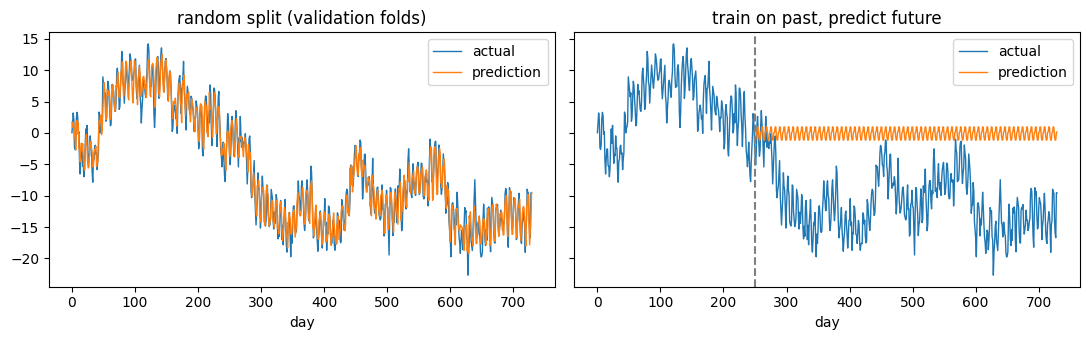

In [ ]:
# 時系列データで、ランダムな分割と時間順の分割のスコアを比べる
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_predict

# 2年分の日次データ: ゆっくり変動する成分（ランダムウォーク）+ 曜日の周期 + 雑音
rng = np.random.default_rng(0)
n_days = 730
day = np.arange(n_days)
series = np.cumsum(rng.normal(scale=1.0, size=n_days)) + 3.0 * np.sin(2 * np.pi * day / 7) + rng.normal(scale=1.0, size=n_days)
# 特徴量は「通し日数」と「曜日」
X_ts = np.column_stack([day, day % 7])
reg = RandomForestRegressor(n_estimators=100, random_state=0)

# 誤り: 日付を無視してランダムに5分割
shuffle_cv = KFold(n_splits=5, shuffle=True, random_state=0)
r2_shuffle = cross_val_score(reg, X_ts, series, cv=shuffle_cv, scoring="r2")
# 正しい: 常に過去で学習し、その直後の期間で検証する
ts_cv = TimeSeriesSplit(n_splits=5)
r2_ts = cross_val_score(reg, X_ts, series, cv=ts_cv, scoring="r2")
print("ランダム分割の決定係数: %.3f" % r2_shuffle.mean())
print("時間順の分割の決定係数: %.3f" % r2_ts.mean(), np.round(r2_ts, 2))

# TimeSeriesSplitが作る分割を確認する
for i, (tr, va) in enumerate(ts_cv.split(X_ts)):
    print("  fold %d: 訓練 %3d〜%3d日目、検証 %3d〜%3d日目" % (i, tr[0], tr[-1], va[0], va[-1]))

# 予測の様子を描く: 左はランダム分割での検証側の予測、右は最初の250日で学習して残りを予測
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
ax[0].plot(day, series, label="actual", linewidth=1)
ax[0].plot(day, cross_val_predict(reg, X_ts, series, cv=shuffle_cv), label="prediction", linewidth=1)
ax[0].set_title("random split (validation folds)")
n_fit = 250
future = reg.fit(X_ts[:n_fit], series[:n_fit]).predict(X_ts[n_fit:])
ax[1].plot(day, series, label="actual", linewidth=1)
ax[1].plot(day[n_fit:], future, label="prediction", linewidth=1)
ax[1].axvline(n_fit, color="gray", linestyle="--")
ax[1].set_title("train on past, predict future")
for a in ax:
    a.set_xlabel("day")
    a.legend()
plt.tight_layout()
plt.show()

### 結果の読み方

同じデータ、同じモデルであるのに、分割の方法だけで評価が正反対になる
- ランダム分割では、決定係数が1に近い
  - 左の図でも、予測は実測によく重なっている
- 時間順の分割では、決定係数が0付近または負になる
  - 決定係数が負であるとは、常に平均値を答えるよりも悪いという意味である
- 右の図を見ると、将来の予測は、学習期間の終わりの水準のまま曜日の周期を繰り返しているだけである
  - その後の水準の変化には、まったく追従できていない
  - 木のモデルは、学習時に見た範囲の外にある「通し日数」に対して、端の値を返すことしかできない

運用時に行うのは右の図の作業であるから、信用すべきは時間順の分割の値である
- ランダム分割の0.96という値は、運用では決して得られない

時系列データでは、分割以外にも「未来の情報」が紛れ込みやすい
- 前日の値などの**ラグ特徴量**は、`shift` の向きを誤ると当日や翌日の値を参照してしまう
- 移動平均を中央揃え（pandasの `rolling(..., center=True)`）で計算すると、未来の値が平均に入る
- 予測する時点ではまだ確定していない値（当日の売上の確定値、後から付与される区分など）を特徴量に入れてしまう
- 特徴量を1つずつ「予測を行う時刻に、この値は本当に手に入るか」と確かめるのが、最も確実な点検である

## 分割の仕方によるリーク：グループ

同じ人、同じ装置、同じ撮影場所から複数の標本が取られているデータでも、同様の問題が起こる
- 同じ患者の測定値は互いによく似ている
- ランダムに分けると、同じ患者の測定が訓練側と検証側の両方に入る
- モデルは「疾患の特徴」ではなく「この患者は誰か」を覚えるだけで正解できる

例えば同じ患者について10回測定した場合、
- 患者Aの測定1 → 訓練
- 患者Aの測定2 → テスト

とするとモデルは患者Aそのものを覚えて高い成績を出せる可能性がある

新しい患者に使うモデルを評価したいのであれば、
- 患者A → 全部訓練
- 患者B → 全部テスト

のように、患者単位で分ける必要がある

`GroupKFold` は、同じグループの標本が必ず同じ側に入るように分割する
- グループを表す番号を `groups` 引数で渡す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-split-group.png" width=700>

上の図は、6人の患者から3回ずつ測定した場合の例である
- 上段では、同じ患者の測定が訓練側と検証側に分かれて入っている
- 下段では、患者EとFの測定がすべて検証側にあり、訓練側には1件も入っていない

In [ ]:
# 同じ人のデータが訓練側と検証側の両方に入る場合と、人ごとに分ける場合を比べる
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

# 100人の患者から10回ずつ測定したデータ（20項目）を作る
# 測定値は患者ごとにほぼ決まっており、測定のたびに少しだけ揺らぐ
rng = np.random.default_rng(0)
n_patient, n_visit = 100, 10
profile = rng.normal(size=(n_patient, 20))
# 疾患の有無は患者ごとに決まり、項目0とだけ弱く関係する
disease = (profile[:, 0] + rng.normal(scale=1.5, size=n_patient) > 0).astype(int)
patient_id = np.repeat(np.arange(n_patient), n_visit)
X_g = profile[patient_id] + rng.normal(scale=0.3, size=(n_patient * n_visit, 20))
y_g = disease[patient_id]

clf = RandomForestClassifier(n_estimators=200, random_state=0)
# 誤り: 測定を単位としてランダムに分割（同じ患者が訓練側と検証側の両方に入る）
acc_random = cross_val_score(clf, X_g, y_g, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0)).mean()
# 正しい: 患者を単位として分割（同じ患者の測定は必ず同じ側に入る）
acc_group = cross_val_score(clf, X_g, y_g, cv=GroupKFold(n_splits=5), groups=patient_id).mean()
print("測定を単位に分割: %.3f" % acc_random)
print("患者を単位に分割: %.3f" % acc_group)

測定を単位に分割: 0.987
患者を単位に分割: 0.635


### 結果の読み方

測定を単位に分けると正解率はほぼ1.0になるが、患者を単位に分けると0.6台まで下がる
- このデータでは、疾患の有無は20項目のうち1項目と弱く関係するだけであり、高い正解率が出るはずがない
- 前者は「すでに知っている患者の、別の日の測定」を当てているにすぎない
- 実際に使う場面では、相手は**初めて見る患者**であるから、後者が実力である

どの単位で分けるかは、「運用時に何が新しくなるのか」で決まる
- 新しい患者に使うなら患者単位、新しい病院に使うなら病院単位、将来に使うなら時間順となる
- 複数の条件が重なる場合（新しい患者の、将来の測定）は、両方を満たすように分ける

分割では、もう1つ、クラスの割合にも注意する
- 少ないクラスがあるデータをランダムに分けると、評価側にそのクラスがほとんど入らないことがある
- `stratify` を指定する**層化（stratification）**は、訓練側と評価側でクラスの割合を揃える
  - グループ単位の分割と層化を同時に行う `StratifiedGroupKFold` もある

## 深層学習やLLMではどう現れるか

深層学習で扱う画像、音声、文章は、表データよりも「互いによく似た標本のまとまり」を作りやすい
- 1つの元データを切り分けて、多数の標本を作ることが多いためである

**同じ出所の標本を、訓練側と評価側にまたがせない**
- 同じ話者の発話、同じ患者の画像、同じ動画から切り出したフレームは、同じ側にまとめる
  - 話者をまたがせると、音声認識や感情認識のモデルは、声の特徴から「誰か」を当てるだけで成績が上がる
- 長い録音を短い区間に切り分ける場合は、切り分ける**前**の録音を単位として分ける（「G-音声処理-2-異常音検知」を参照）
- 長い文書を段落や一定の長さの断片（チャンク）に分ける場合も、文書を単位として分ける
  - 同じ文書の隣り合うチャンクは、話題も言い回しも共通している

**データ拡張は、分割の後で訓練側にだけ行う**
- 画像の反転や切り抜き、音声への雑音の付加で標本を増やす**データ拡張（data augmentation）**は、分割の後で、訓練側にだけ適用する
- 拡張してから分割すると、同じ元画像から作った標本が両側に入り、グループのリークとなる
  - 「不均衡への対処の比較」の節で述べる「複製してから分割する」誤りと同じ構造である
- 評価側には拡張を行わず、運用時と同じ形の入力で測る

**重複と、ほぼ重複した標本を調べる**
- ウェブから集めたデータには、同じ画像の縮小版、転載された同じ文章などが含まれる
- 重複は、分割の**前**に取り除くか、同じ側にまとめる
  - 分割してから片側ずつ重複を除いても、両側にまたがる重複は残る
- 公開のデータセットをそのまま使う場合も、訓練用と評価用の間に重複がないとは限らない

**時系列は未来を見ない**
- 需要予測、株価、センサの異常検知など、時刻を持つデータでは、モデルの種類によらず時間順に分ける
- 入力の窓（過去何点を見るか）が、評価側の期間に食い込まないようにする
- LLMの評価でも時間が関係する
  - モデルの学習データが集められた時点より前に公開された問題は、学習データに含まれている可能性がある
  - 学習より後に作られた問題で測るのは、「過去で学習し、未来で評価する」という時間順の分割と同じ考え方である

**検索を使うシステム**
- 文書を検索して回答に使うシステム（RAG）の評価では、質問と正解の組を、訓練用（調整用）と評価用に分ける
- 同じ文書から作った質問が両側に入ると、その文書に合わせた調整が評価を良く見せる
  - 質問を単位にランダムに分けるのではなく、元の文書を単位に分ける

**評価側は、運用時のデータを代表しているか**
- 分割が正しくても、手元のデータ全体が運用時のデータと異なっていれば、評価は当てにならない
  - 例として、昼に撮影した画像だけで評価したモデルを夜に使う場合、ある工場の機械の音で評価したモデルを別の工場で使う場合が挙げられる
- 「運用時に何が新しくなるのか」という問いは、分割の単位だけでなく、評価用のデータに何を含めるべきかも決める

---

# 不均衡データと評価指標

## 原則

故障検知、不正利用の検出、疾患の診断のように、見つけたいクラス（陽性）がごくわずかしか存在しない問題は多い

これは既に述べた通りであり、例えば、
- 正常 97%
- 異常  3%

の故障検知の場合、すべてを正常と答えるだけで正解率は97%になるため、正解率だけでは性能を判断できない

- このようなデータを**不均衡データ（imbalanced data）**と呼ぶ
- 「2-ML基礎」の章で、全て陰性と答えるだけで正解率（Accuracy）が高くなることを確認した

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-accuracy-imbalance.png" width=650>

上の図は、100件のうち陽性が3件の場合である
- 何も学習せずに全件を陰性と答えても、97件は当たるため正解率は0.97となる
- 見つけたかった陽性は1件も見つけていない

ここから、指標についての原則が2つ得られる
- **指標は、目的に合わせて選ぶ**
  - 1つの数値は、モデルの振る舞いの一面しか表さない
  - 何を見逃すと困るのか、何を誤って検出すると困るのかを先に決め、それを測る指標を使う
- **何も学習しない方法の成績と必ず比べる**
  - 常に多数派を答える方法や、でたらめに答える方法の値を基準として並べる
  - 基準を上回っていない数値は、どれほど高く見えても意味を持たない

ここでは、次の2点を扱う
- 評価: 適合率（Precision）と再現率（Recall）、および両者の関係を描く**PR曲線（Precision-Recall curve）**
- 対処: `class_weight`、しきい値の調整、アンダーサンプリング、オーバーサンプリング

PR曲線は、陽性と判定するしきい値を動かしたときの、再現率（横軸）と適合率（縦軸）の関係を描いたものである
- ROC曲線の横軸である偽陽性率は、分母が陰性の総数であるため、陰性が大量にあると誤検出が多くても小さく見える
- 適合率の分母は「陽性と判定した件数」であるため、誤検出が増えるとそのまま値が下がる
- 曲線の下の面積に相当する値を**平均適合率（Average Precision、AP）**と呼ぶ
  - でたらめに答えた場合のAPは、ROC-AUCのような0.5ではなく、陽性の割合に等しくなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-threshold-tradeoff.png" width=750>

上の図は、しきい値を動かしたときに起こることを模式的に描いたものである
- 横軸はモデルが出力する確率であり、しきい値より右にある標本を陽性と判定する
- しきい値が高い（左の図）と、陽性の多くがしきい値の左に残り、見逃しとなる
- しきい値を下げる（右の図）と、見逃しは減るが、陰性の山の裾がしきい値の右に入り、誤検出が増える
- PR曲線は、しきい値を端から端まで動かしたときの、この入れ替わりを1本の線にまとめたものである

まず、陽性が約3%のデータを作り、正解率がどれほど当てにならないかを数値で確かめる

陽性の割合: 0.029
常に陰性と答える               正解率 0.971  適合率 0.000  再現率 0.000  F1 0.000
ロジスティック回帰              正解率 0.971  適合率 0.611  再現率 0.062  F1 0.113
ROC-AUC 0.862  AP 0.245


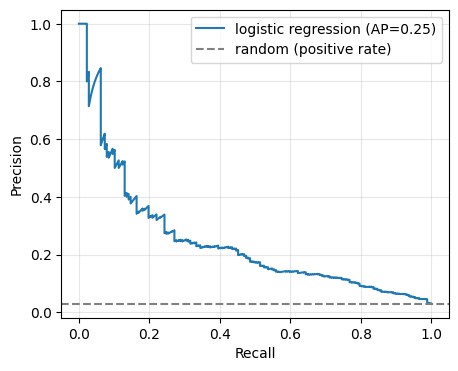

In [ ]:
# 陽性が約3%のデータで、正解率、適合率、再現率、PR曲線を確認する
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score, precision_recall_curve)

# 陰性は原点を中心とする正規分布、陽性は10列のうち先頭4列だけを0.75ずつずらした正規分布とする
rng = np.random.default_rng(0)
n = 20000
y = (rng.random(n) < 0.03).astype(int)
X = rng.normal(size=(n, 10))
X[y == 1, :4] += 0.75
# stratifyを指定し、訓練とテストで陽性の割合を揃える
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print("陽性の割合: %.3f" % y.mean())

# 常に多数派（陰性）と答えるだけのモデル
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
# 通常のロジスティック回帰
base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)

def report(name, y_true, y_pred):
    # 正解率、適合率、再現率、F1値を1行で表示する
    print("%-22s 正解率 %.3f  適合率 %.3f  再現率 %.3f  F1 %.3f" % (
        name, accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred), f1_score(y_true, y_pred)))

report("常に陰性と答える", y_test, dummy.predict(X_test))
report("ロジスティック回帰", y_test, base.predict(X_test))

# しきい値に依存しない指標
prob = base.predict_proba(X_test)[:, 1]
print("ROC-AUC %.3f  AP %.3f" % (roc_auc_score(y_test, prob), average_precision_score(y_test, prob)))

# PR曲線を描く
prec, rec, thr = precision_recall_curve(y_test, prob)
plt.figure(figsize=(5, 4))
plt.plot(rec, prec, label="logistic regression (AP=%.2f)" % average_precision_score(y_test, prob))
plt.axhline(y_test.mean(), color="gray", linestyle="--", label="random (positive rate)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 結果の読み方

結果から、次のことが読み取れる
- 何も学習していない「常に陰性」のモデルと、ロジスティック回帰の正解率は、ほとんど変わらない
  - 正解率だけを見ていると、両者を区別できない
- ロジスティック回帰の再現率は低く、陽性の大半を見逃している
  - 既定のしきい値0.5は「陽性である確率が半分を超えたら陽性」という意味である
  - 陽性がもともと3%しかないため、確率が0.5を超える標本は少ない
- ROC-AUCは高い値であるのに、APはそれよりかなり低い
  - 同じモデルでも、どの指標で見るかによって印象が大きく変わる
- PR曲線を見ると、再現率を上げるほど適合率が下がることがわかる
  - 見逃しを減らすか、誤検出を減らすかは両立せず、どこで折り合うかを決める必要がある

モデルは陽性と陰性をある程度**順位付け**できているが、しきい値0.5という**線引き**が不均衡データに合っていない
- 以下の対処は、いずれもこの線引きを動かす方法と捉えると理解しやすい

## 不均衡への対処の比較

代表的な対処は次の4つである
- `class_weight="balanced"`: 損失関数の中で、少数派の誤りに大きな重みを付ける
  - 重みは、クラスの件数に反比例するように自動で決まる
  - データはそのまま使うため、情報を捨てず、学習時間もほとんど増えない
- **しきい値の調整**: モデルは変えず、陽性と判定する確率の境界を0.5から動かす
  - しきい値はテストデータで決めてはならず、訓練データから切り出した検証用データで決める
  - 例えば、分類モデルが出す確率について、```p > 0.5 → 陽性```とする必要はなく、見逃しを減らしたければ、```p > 0.1 → 陽性```とすることもできる

- **アンダーサンプリング（undersampling）**: 多数派を間引いて件数を揃える
  - 学習は速くなるが、多数派の情報を捨てることになる
- **オーバーサンプリング（oversampling）**: 少数派を重複ありで複製して件数を揃える
  - 情報は捨てないが、同じ標本を何度も学習するため、柔軟なモデルでは過学習しやすい
  - 複製ではなく近傍の標本の間を補間して新しい標本を作るSMOTEという方法もあるが、ここでは扱わない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-resampling.png" width=700>

上の図は、3つの対処がデータに対して何を行うかを模式的に示している
- サンプリングは標本の件数を変え、`class_weight` は件数を変えずに損失の中での重みを変える

サンプリングは訓練データにだけ行う点が重要である
- テストデータまで件数を揃えると、本番と異なる割合で評価することになり、適合率が実際より高く出る
- 交差検証と組み合わせる場合は、分割の**後**で訓練側にだけ行う
  - 複製してから分割すると、同じ標本が訓練側と検証側の両方に入り、データリークとなる

追加のパッケージを使わず、NumPyの添字操作だけでサンプリングを書いて比較する

In [ ]:
# class_weight、しきい値の調整、アンダーサンプリング、オーバーサンプリングを同じテストデータで比べる
def make_lr(**kw):
    # 比較条件を揃えるため、すべて同じ構成のロジスティック回帰を使う
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, **kw))

rng = np.random.default_rng(0)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

# アンダーサンプリング: 陰性を、陽性と同じ件数だけ重複なしで抜き出す
under_idx = np.concatenate([pos_idx, rng.choice(neg_idx, size=len(pos_idx), replace=False)])
# オーバーサンプリング: 陽性を、陰性と同じ件数になるまで重複ありで抜き出す
over_idx = np.concatenate([neg_idx, rng.choice(pos_idx, size=len(neg_idx), replace=True)])
print("訓練データ %d件（陽性 %d件） → アンダー %d件、オーバー %d件" % (
    len(y_train), len(pos_idx), len(under_idx), len(over_idx)))

# しきい値の調整: 訓練データをさらに分け、検証用データでF1値が最大になるしきい値を選ぶ
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25,
                                              stratify=y_train, random_state=0)
val_prob = make_lr().fit(X_fit, y_fit).predict_proba(X_val)[:, 1]
p_val, r_val, t_val = precision_recall_curve(y_val, val_prob)
f1_val = 2 * p_val[:-1] * r_val[:-1] / np.maximum(p_val[:-1] + r_val[:-1], 1e-12)
best_thr = t_val[np.argmax(f1_val)]
print("検証用データで選んだしきい値: %.3f" % best_thr)

models = {
    "対処なし": make_lr().fit(X_train, y_train),
    "class_weight": make_lr(class_weight="balanced").fit(X_train, y_train),
    "アンダーサンプリング": make_lr().fit(X_train[under_idx], y_train[under_idx]),
    "オーバーサンプリング": make_lr().fit(X_train[over_idx], y_train[over_idx]),
}
print()
for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    report(name, y_test, (p >= 0.5).astype(int))
    print("%-22s AP %.3f" % ("", average_precision_score(y_test, p)))
# しきい値の調整は「対処なし」と同じモデルで、境界だけを変える
p = models["対処なし"].predict_proba(X_test)[:, 1]
report("しきい値の調整", y_test, (p >= best_thr).astype(int))
print("%-22s AP %.3f" % ("", average_precision_score(y_test, p)))

訓練データ 14000件（陽性 412件） → アンダー 824件、オーバー 27176件
検証用データで選んだしきい値: 0.124

対処なし                   正解率 0.971  適合率 0.611  再現率 0.062  F1 0.113
                       AP 0.245
class_weight           正解率 0.766  適合率 0.094  再現率 0.802  F1 0.168
                       AP 0.244
アンダーサンプリング             正解率 0.765  適合率 0.094  再現率 0.808  F1 0.169
                       AP 0.236
オーバーサンプリング             正解率 0.766  適合率 0.094  再現率 0.802  F1 0.168
                       AP 0.241
しきい値の調整                正解率 0.938  適合率 0.219  再現率 0.435  F1 0.291
                       AP 0.245


### 結果の読み方

この表は、数値の大小よりも**動き方**を読むとよい

- `class_weight`、アンダーサンプリング、オーバーサンプリングは、互いによく似た結果になる
  - いずれも再現率が大きく上がり、その代わりに適合率と正解率が下がる
  - 3つとも「陽性と陰性を同じ重さで扱う」という同じ効果を、別の手段で実現しているためである
- APは、どの方法でもほとんど変わらない
  - APはしきい値に依存せず、陽性を上位に並べる能力を測る指標である
  - つまり、これらの対処はモデルの順位付けの能力を上げたのではなく、PR曲線の上で**動作点を移動させた**だけである
- しきい値の調整は、同じ曲線の上で、目的に合う点を直接選ぶ方法である
  - ここではF1値が最大となる点を選んだため、「対処なし」と重み付けの中間にあたる点になっている

実務での進め方をまとめる
- まず、見逃し1件と誤検出1件のどちらがどれだけ困るのかを、業務の側から決める
  - 例えば疾患の一次検査では見逃しが重く、迷惑メールの判定では誤検出が重い
- 次に、`class_weight` またはしきい値の調整を試す（追加の費用がほとんどかからないため）
- サンプリングは、データが大きすぎて学習時間を減らしたい場合（アンダー）などに選ぶ
- 順位付けの能力そのもの（AP）を上げるには、特徴量を増やす、モデルを変えるなど、別の努力が必要である

なお、重み付けやサンプリングを行ったモデルが出力する確率は、実際の陽性の割合よりも高い方へずれる
- 確率の値そのものを使う場合（期待損失の計算など）は、校正（calibration）が別途必要となる

## 深層学習やLLMではどう現れるか

不均衡は、深層学習の対象でもごく普通に現れる
- 画像の中の物体を探す問題では、物体のある場所より、何もない背景の方がはるかに多い
- 医用画像の病変、製造ラインの不良品、機械の異常音は、正常なデータに比べてわずかしかない
- 文章の分類でも、有害な投稿や不正な取引の記述は全体のごく一部である

対処の方法は、上で比べた3つとそのまま対応する

**損失の重み付け**
- `class_weight` に相当するのは、損失関数の中でクラスごとに重みを掛けることである
  - PyTorch では、`nn.CrossEntropyLoss` の `weight` 引数、`nn.BCEWithLogitsLoss` の `pos_weight` 引数がこれにあたる
- **focal loss** は、すでに高い確率で正しく分類できている標本の損失を小さくし、難しい標本に学習を集中させる損失関数である
  - 物体検出で、容易に分類できる背景が損失の大半を占めてしまう問題への対処として提案された

**サンプラ**
- オーバーサンプリングとアンダーサンプリングに相当するのは、ミニバッチを作るときに標本を選ぶ確率を変えることである
  - PyTorch では、`WeightedRandomSampler` を `DataLoader` に渡すと、少数派の標本を選ばれやすくできる
- サンプリングを変えるのは訓練データだけであり、検証データとテストデータは元の割合のまま評価する

**出力される確率はずれる**
- 重み付けもサンプラも、上の実験と同じく、モデルの順位付けの能力を上げるのではなく、動作点を動かす
- 出力される確率は、実際の陽性の割合よりも高い方へずれる
  - 確率の値を使う場合は、次の節の校正が必要となる

**指標の選び方**
- 画像の領域分割で、背景の画素が大半を占める場合、画素単位の正解率は「全て背景」と答えても高くなる
  - 領域の重なりを測るIoUやDice係数を用いるのは、正解率の代わりに適合率と再現率を用いるのと同じ理由による
- 物体検出の評価に使うAPは、ここで扱ったAPと同じ考え方の指標である
- LLMの出力を分類や判定に使う場合も、正解率だけを報告せず、多数派を常に答える方法の値と並べる
  - 有害な入力の検出では、見逃し率と誤検知率を分けて測る（「T-安全性と公平性」を参照）

**評価用の陽性の件数**
- 陽性が少ないと、評価用データに含まれる陽性も少なく、再現率の値は数件の当たり外れで大きく動く
- 陽性が20件しかなければ、1件の違いで再現率は0.05変わる
  - 小さな差を「改善した」と判断する前に、件数から見て意味のある差かを確かめる（「M-LLM-4-評価」の「規模と統計的な誤差」の節を参照）

---

# 確率の校正

## 原則

分類モデルの多くは、クラスだけでなく確率を出力する
- この確率を**数値として信用してよいか**は、正解率やAPとは別に確かめる必要がある

モデルが「陽性である確率は0.3」と出力した標本を集めたとき、そのうち実際に3割が陽性であれば、確率は**校正（calibration）されている**という

つまり、分類器が、このデータは異常である確率 80%と出したとしても、本当に80%の確率で異常とは限らない
- **Calibration（校正）**とは、80%と予測されたデータを100件集めたら、実際に約80件が陽性になるような状態をいう
- 分類の正解率が高いことと、確率が正しいことは別問題である

したがって、

- 順位付けが正しいこと（ROC-AUCやAPが高いこと）と、確率の値が正しいことは別の性質である
- 確率の値を使う場面では校正が必要となる
  - 例: 「故障確率が1%を超えたら点検する」「期待損失 = 確率 × 損害額 を計算する」「確信が低い場合は人に回す」

前の節で、重み付けやサンプリングを行うと出力される確率がずれる、と述べた
- これを実際に確かめる

確かめる道具は2つある
- **信頼性曲線（reliability curve）**: 予測確率の近い標本をまとめ、横軸に予測確率の平均、縦軸に実際の陽性の割合を描く
  - 校正されていれば、対角線 $y=x$ に乗る
- **Brierスコア**: 予測確率と正解（0か1）の差の2乗の平均であり、小さいほどよい

ずれている場合は、`CalibratedClassifierCV` で補正できる
- モデルの出力を、実際の陽性の割合に合うように変換する関数を、追加で学習する
- 変換の学習に、モデルの学習と同じデータを使うと楽観的な補正になるため、内部で交差検証を行う
  - 「データから値を決める操作」であるから、テストデータで行ってはならない
- `method="sigmoid"` はS字の関数1つで補正する
  - `method="isotonic"` はより柔軟であるが、データが少ないと過学習しやすい

テストデータの実際の陽性の割合: 0.029
no weighting                 予測確率の平均 0.032  Brier 0.0253  AP 0.245
class_weight                 予測確率の平均 0.324  Brier 0.1597  AP 0.244
class_weight + calibration   予測確率の平均 0.032  Brier 0.0252  AP 0.244


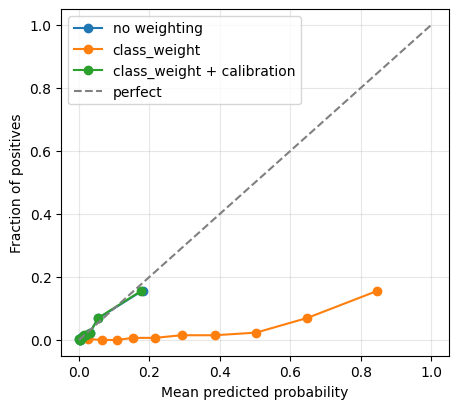

In [ ]:
# 予測確率が実際の陽性の割合と合っているかを、信頼性曲線とBrierスコアで確かめる
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# class_weightを付けたモデルを、交差検証を使って校正する
calibrated = CalibratedClassifierCV(make_lr(class_weight="balanced"), method="sigmoid", cv=5).fit(X_train, y_train)
targets = {
    "no weighting": models["対処なし"],
    "class_weight": models["class_weight"],
    "class_weight + calibration": calibrated,
}
print("テストデータの実際の陽性の割合: %.3f" % y_test.mean())
plt.figure(figsize=(5, 4.5))
for name, m in targets.items():
    p = m.predict_proba(X_test)[:, 1]
    # 予測確率の小さい順に10等分し、区間ごとに「予測確率の平均」と「実際の陽性の割合」を求める
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
    print("%-28s 予測確率の平均 %.3f  Brier %.4f  AP %.3f" % (
        name, p.mean(), brier_score_loss(y_test, p), average_precision_score(y_test, p)))
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 結果の読み方

`class_weight` を付けたモデルは、予測確率の平均が0.3を超えており、実際の陽性の割合（約0.03）の10倍になっている
- 信頼性曲線も対角線の大きく下にある
  - 「確率0.8」と出力された標本の集まりでも、実際の陽性は2割に満たない
- 陽性を約30倍の重さで学習したため、モデルは陽性が半分を占める世界の確率を答えている
- Brierスコアも、重みなしのモデルよりはるかに大きい

校正を行うと、予測確率の平均は実際の割合に戻り、信頼性曲線は対角線に乗る
- 図では、重みなしのモデルの線と校正後の線がほぼ重なっている
- APは3つとも変わらない
  - 校正は順位を変えない変換であるため、順位付けの能力は良くも悪くもならない

ロジスティック回帰は、重み付けをしなければ、もともとよく校正された確率を出力する
- ランダムフォレスト、SVM、ブースティングなどは、重み付けをしなくても確率がずれることが多い
- 確率の値を使う場合は、モデルの種類によらず信頼性曲線を確認するとよい

## 深層学習やLLMではどう現れるか

ニューラルネットワークの分類器は、最後の層の出力（ロジット）に softmax をかけて確率を得る
- 最大の確率を、その予測に対する**確信度（confidence）** として使うことが多い
- 層が深く表現力の高いネットワークは、正解率が高くても、確信度が実際の正解率より高くなりすぎる傾向があることが知られている
  - 一因として、訓練データを正しく分類できるようになった後も、損失を下げようとしてロジットの大きさが増え続けることが挙げられる

つまり、FC層→logit→softmax→確率として確率を得ることが多いが、深いニューラルネットワークは、間違っているのに99%と答えるなど、過剰に自信を持つことがあるため、softmaxの値をそのまま「本当の確率」と考えてはいけない

**温度スケーリング（temperature scaling）** は、この過信を直す最も簡単な方法である
- ロジットを1つの正の数 $T$（温度）で割ってから softmax をかける

$$p_k = \frac{\exp(z_k / T)}{\sum_j \exp(z_j / T)}$$

- $T>1$ とすると確率の分布がなだらかになり、確信度が下がる
- $T$ は、**検証データ** の交差エントロピーが最小になるように決める
  - 決める値が1つだけであるため、検証データが少なくても過学習しにくい
- すべてのロジットを同じ数で割るだけであるから、どのクラスが最大かは変わらず、正解率は変化しない
  - 上の `CalibratedClassifierCV` と同じく、順位を変えずに確率の値だけを直す操作である

これを、scikit-learn のニューラルネットワーク（`MLPClassifier`）で確かめる
- 少ない訓練データを覚え込むまで学習し、過信の状態を作る
- 確信度と正解率のずれは、**ECE（Expected Calibration Error）** で測る
  - 確信度の近い標本をまとめ、区間ごとの「確信度の平均と正解率の差」を、件数の割合で重み付けして足した値であり、0に近いほどよい
- `MLPClassifier` はロジットを直接返さないため、確率の対数をロジットの代わりに使う
  - 確率の対数は、ロジットから標本ごとの定数を引いたものであり、softmax をかけ直した結果は同じになる

In [ ]:
# 過学習したニューラルネットワークの確信度を、温度スケーリングで校正する
import numpy as np
from scipy.optimize import minimize_scalar
from sklearn.neural_network import MLPClassifier

# 3クラスの合成データ: クラスごとに中心の異なる正規分布（重なりが大きく、完全には分けられない）
rng = np.random.default_rng(0)
centers = 0.6 * rng.normal(size=(3, 10))
def make_blobs3(n):
    label = rng.integers(0, 3, size=n)
    return centers[label] + rng.normal(size=(n, 10)), label

X_tr3, y_tr3 = make_blobs3(300)     # 訓練データ（少なめにして過学習させる）
X_va3, y_va3 = make_blobs3(1000)    # 検証データ（温度を決める）
X_te3, y_te3 = make_blobs3(5000)    # テストデータ

# 中間層が2層のニューラルネットワークを、訓練データをほぼ覚え込むまで学習する
net = MLPClassifier(hidden_layer_sizes=(256, 256), alpha=0.0, max_iter=500, random_state=0).fit(X_tr3, y_tr3)
print("訓練データの正解率: %.3f" % net.score(X_tr3, y_tr3))

def scaled_proba(model, X, T):
    # 確率の対数（ロジットと定数の差しかない）を温度Tで割り、softmaxをかけ直す
    z = np.log(np.clip(model.predict_proba(X), 1e-12, 1.0)) / T
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z)
    return p / p.sum(axis=1, keepdims=True)

def nll(p, y):
    # 交差エントロピー（正解クラスの確率の対数の平均に負号を付けたもの）
    return -np.mean(np.log(p[np.arange(len(y)), y]))

# 温度Tを1つだけ決める: 検証データの交差エントロピーが最小になるTを探す
opt = minimize_scalar(lambda log_t: nll(scaled_proba(net, X_va3, np.exp(log_t)), y_va3), bounds=(-3, 5), method="bounded")
T = np.exp(opt.x)
print("検証データで決めた温度 T: %.2f" % T)

def summarize(name, p, y):
    # 正解率、確信度（最大の確率）の平均、交差エントロピー、ECEを表示する
    conf, correct = p.max(axis=1), (p.argmax(axis=1) == y)
    # ECE: 確信度を10区間に分け、区間ごとの「確信度の平均と正解率の差」を件数の割合で重み付けして足す
    ece = 0.0
    for lo in np.linspace(0, 0.9, 10):
        mask = (conf > lo) & (conf <= lo + 0.1)
        if mask.any():
            ece += mask.mean() * abs(conf[mask].mean() - correct[mask].mean())
    print("%-6s 正解率 %.3f  確信度の平均 %.3f  交差エントロピー %.3f  ECE %.3f" % (
        name, correct.mean(), conf.mean(), nll(p, y), ece))

summarize("校正前", scaled_proba(net, X_te3, 1.0), y_te3)
summarize("校正後", scaled_proba(net, X_te3, T), y_te3)

訓練データの正解率: 1.000
検証データで決めた温度 T: 4.74
校正前    正解率 0.755  確信度の平均 0.945  交差エントロピー 1.404  ECE 0.190
校正後    正解率 0.755  確信度の平均 0.764  交差エントロピー 0.579  ECE 0.013


### 結果の読み方

校正前は、確信度の平均が0.9を超えているのに、正解率は0.75前後である
- モデルは、実際よりも2割近く自分の答えを信じすぎている
- 訓練データの正解率が1.0であることから、訓練データを覚え込んでいることがわかる

温度スケーリングの後は、確信度の平均が正解率とほぼ一致し、ECEは10分の1以下になる
- 決まった温度は1より大きく、確率の分布をなだらかにする方向の補正である
- 正解率は校正の前後でまったく変わらない
- 交差エントロピーは大きく下がる
  - 交差エントロピーは、自信を持って間違えた標本に大きな罰を与えるため、過信が直ると下がる

深層学習とLLMで、校正に関して注意する点を挙げる
- **確信度をそのまま確率として使わない**
  - 「確信度が0.9以上のものだけを自動で処理する」という運用を行う前に、検証データで信頼性曲線かECEを確かめる
- **校正は、測ったデータの分布でしか保証されない**
  - 運用時のデータが訓練時と異なる場合、検証データで合わせた温度が合わなくなることがある
- **不均衡への対処は校正を崩す**
  - 損失の重み付け、focal loss、サンプラはいずれも確率をずらすため、確率を使うなら校正し直す
- **LLMの生成で使う温度と、式は同じである**
  - 文章を生成するときの `temperature` も、次のトークンのロジットを $T$ で割る操作である
  - 生成では出力の多様さを調整する目的で使い、ここでは確率の値を実際の頻度に合わせる目的で使う
- **LLMが文章として述べる自信は、確率ではない**
  - 「この答えには自信がある」という文面は生成された文章であり、その正しさは別に測る必要がある
  - LLMを採点者として使う場合に、採点の結果を人の判断と突き合わせて確かめるのも、同じ考え方による（「M-LLM-4-評価」を参照）

---

# 費用を考慮したしきい値の決定

## 原則

モデルが出力するのは確率やスコアであり、「陽性と判定する」という**行動**に変えるには、どこかに線を引く必要がある
- 既定の0.5という線引きは、多くの場合、誰も選んでいない値である
- **線引きは、誤りの費用から決める**

「不均衡への対処の比較」ではF1値が最大となる点を選んだ
- F1値は適合率と再現率を対等に扱うが、実際の業務で見逃しと誤検出の損失が等しいことはまれである
- 損失を見積もれるなら、**費用の合計が最小になるしきい値**を直接選ぶ方が目的に合う

たとえば、通常、```確率 > 0.5 → 陽性```とすることが多いが、0.5に特別な意味があるわけではない
- 故障検出で、
```
故障を1件見逃す損失 = 100万円
誤警報1件の損失     = 1万円
```
なら、多少誤警報が増えても見逃しを減らした方がよい
- したがって、実際の損失が最も小さくなるしきい値を選ぶことが重要


見逃し（偽陰性）1件の費用を $c_{FN}$、誤検出（偽陽性）1件の費用を $c_{FP}$ とする
- ある標本が陽性である確率を $p$ とすると、陰性と判定したときの期待費用は $p \, c_{FN}$、陽性と判定したときの期待費用は $(1-p) \, c_{FP}$ である
- 陽性と判定した方が得になるのは $(1-p) \, c_{FP} < p \, c_{FN}$ のとき、すなわち次の場合である

$$p > \frac{c_{FP}}{c_{FP} + c_{FN}}$$

- 費用が等しければ、しきい値は0.5となる
  - 既定の0.5は「見逃しと誤検出が同じ重さ」という仮定に相当する
- 見逃しが重いほど、しきい値は小さくなる
- この式が成り立つのは、$p$ が校正された確率である場合に限る
  - 前の節の校正が、ここで必要になる

ここでは、見逃し1件が誤検出20件分に相当するとして、検証用データでしきい値を探し、式の値と比べる

検証用データで費用が最小のしきい値: 0.045
理論上のしきい値 c_FP/(c_FP+c_FN) : 0.048
全件を陰性とした場合の費用: 3540
既定の0.5       しきい値 0.500  費用   3327  適合率 0.611  再現率 0.062
F1値が最大       しきい値 0.124  費用   2275  適合率 0.219  再現率 0.435
費用が最小        しきい値 0.045  費用   1939  適合率 0.121  再現率 0.712
理論値          しきい値 0.048  費用   1950  適合率 0.124  再現率 0.695


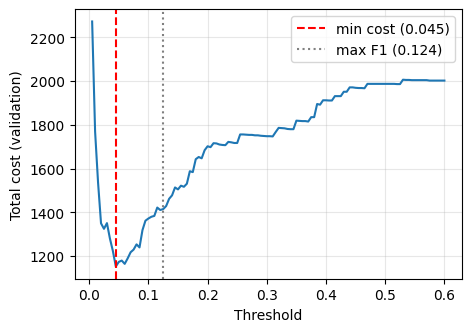

In [ ]:
# 見逃しと誤検出の費用を決め、費用の合計が最小になるしきい値を選ぶ
cost_fn, cost_fp = 20.0, 1.0   # 見逃し1件は、誤検出20件分の損失とする

def total_cost(y_true, prob, thr):
    # しきい値thrで判定したときの費用の合計
    pred = prob >= thr
    n_fn = np.sum((y_true == 1) & ~pred)
    n_fp = np.sum((y_true == 0) & pred)
    return cost_fn * n_fn + cost_fp * n_fp

# 検証用データ（しきい値の調整で作ったもの）で、しきい値ごとの費用を計算する
grid = np.linspace(0.005, 0.6, 120)
val_cost = np.array([total_cost(y_val, val_prob, t) for t in grid])
thr_cost = grid[np.argmin(val_cost)]
# 確率が校正されている場合の理論上の最適値
thr_theory = cost_fp / (cost_fp + cost_fn)
print("検証用データで費用が最小のしきい値: %.3f" % thr_cost)
print("理論上のしきい値 c_FP/(c_FP+c_FN) : %.3f" % thr_theory)

# テストデータで、しきい値ごとの費用を比べる
p_test = models["対処なし"].predict_proba(X_test)[:, 1]
print("全件を陰性とした場合の費用: %.0f" % (cost_fn * y_test.sum()))
for name, t in [("既定の0.5", 0.5), ("F1値が最大", best_thr), ("費用が最小", thr_cost), ("理論値", thr_theory)]:
    pred = (p_test >= t).astype(int)
    print("%-12s しきい値 %.3f  費用 %6.0f  適合率 %.3f  再現率 %.3f" % (
        name, t, total_cost(y_test, p_test, t), precision_score(y_test, pred, zero_division=0), recall_score(y_test, pred)))

plt.figure(figsize=(5, 3.5))
plt.plot(grid, val_cost)
plt.axvline(thr_cost, color="red", linestyle="--", label="min cost (%.3f)" % thr_cost)
plt.axvline(best_thr, color="gray", linestyle=":", label="max F1 (%.3f)" % best_thr)
plt.xlabel("Threshold")
plt.ylabel("Total cost (validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 結果の読み方

検証用データで探したしきい値は、式から求めた値 $1/21 \approx 0.048$ とほぼ一致する
- 重みなしのロジスティック回帰の確率が、よく校正されているためである
- `class_weight` を付けたモデルの確率に同じ式を当てはめると、誤ったしきい値になる

テストデータでの費用を比べる
- 既定の0.5では、全件を陰性とした場合とほとんど変わらない費用がかかる
- F1値が最大のしきい値でも改善するが、費用が最小のしきい値はさらに低い位置にある
  - 適合率は0.12前後まで下がる
    - 陽性と判定した8件のうち7件が誤検出である
  - それでも、見逃しが20倍重いという前提の下では、この点が最も損失が小さい
- 図を見ると、最小点の左側では費用が急に増え、右側ではゆるやかに増える
  - しきい値を下げすぎると、大量の陰性を陽性と判定してしまうためである

しきい値の決定についてまとめる
- 適合率が低いことは、それだけでは悪いことではない
  - 費用の比によって最適な点は変わる
- 費用の比を決めるのは、機械学習の側ではなく業務の側である
  - まず関係者とその比を合意する
- 費用を金額で表せない場合は、「再現率を0.9以上に保つ」「1日の警報を100件以内にする」などの制約を先に決め、その中で最良の点を選ぶ
- しきい値は検証用データで決め、テストデータでは決めた値を確認するだけにする
- 運用中に陽性の割合が変わると、最適なしきい値も変わるため、定期的に見直す

## 深層学習やLLMではどう現れるか

スコアに線を引いて行動に変える場面は、深層学習を使うシステムのいたるところにある

- **物体検出**: 検出の確信度がしきい値を超えたものだけを結果として出力する
  - しきい値を下げれば見逃しは減り、誤検出は増える
  - 自動運転の歩行者検出と、写真の整理のための物体検出とでは、適切な線引きが異なる
- **異常検知**: 異常度がしきい値を超えたら警報を出す
  - 異常はきわめてまれであるため、わずかな誤検出率でも、警報の大半が誤報になりうる（「G-音声処理-2-異常音検知」を参照）
- **入出力の検査**: LLMへの入力や出力が有害かどうかを分類器で判定し、スコアがしきい値を超えたら遮断する
  - 見逃しと、無害な利用者を妨げる誤検知の、どちらをどれだけ許すかを決める問題である（「T-安全性と公平性」を参照）
- **モデルの使い分け**: 小さいモデルの確信度が低い場合だけ、大きいモデルや人に回す
  - しきい値は、誤答の費用と、大きいモデルを呼ぶ費用の比で決まる（「S-推論サービング」を参照）
  - 確信度が校正されていなければ、この判断は狂う
- **回答を控える**: 確信度が低い質問には「わからない」と答えさせる
  - 誤った回答の費用が、回答しないことの費用より大きい場合に意味を持つ

どの場面でも、守ることは同じである
- しきい値は検証データで決め、テストデータでは決めた値を確認するだけにする
- 費用の比は、モデルを作る側ではなく、使う側の事情で決まる
- 陽性の割合や入力の分布が変われば、最適な線引きも変わるため、運用中も見直す

---

# 特徴選択と重要度

## 原則

モデルに何を入力するかは、モデルの種類と同じくらい結果を左右する
- この節の原則は2つある
- **入力は多ければよいわけではない**
  - 目的変数と無関係な入力は、訓練データの偶然の傾向を拾う材料となり、過学習を招く
  - 入力が少ないほど、学習と推論が速く、データの収集と保守の費用も下がる
  - どの入力が使われているかを説明しやすくなる
  - つまり、不要な特徴量が多いと、過学習、学習時間の増加、推論時間の増加、説明性の低下を招く

- **モデルが何を使って予測しているかを、未知のデータで確かめる**
  - 訓練データの上で「よく使われた」入力が、未知のデータで役に立っているとは限らない

使う特徴量を絞り込む操作を**特徴選択（feature selection）**と呼び、方法は大きく3つに分けられる
- **フィルタ法（filter method）**: モデルを使わず、特徴量ごとに目的変数との関係の強さを統計量で採点し、上位を残す
  - 各特徴量をモデルとは独立に評価する
  - 例えば、この特徴量単独で目的変数とどれだけ関係があるかを調べ、上位だけを使用
  - 高速で簡単だが、複数の特徴量を組み合わせたときに初めて意味を持つ特徴を見落とすことがある
  - `SelectKBest` が該当し、採点には分散分析のF値（`f_classif`）や相互情報量（`mutual_info_classif`）を使う
  - 高速であるが、1列ずつ別々に採点するため、組み合わせて初めて効く特徴量や、重複した特徴量を考慮できない

- **ラッパー法（wrapper method）**: 実際にモデルを学習し、その結果を見て特徴量を増減させることを繰り返す
  - 実際にモデルを学習しながら、どの特徴量の組み合わせが最も良いかを調べる手法
  - `RFE`（Recursive Feature Elimination、再帰的特徴削減）が該当する
    - 全特徴量で学習し、係数や重要度が最も小さいものを除き、残りで学習し直す、という手順を繰り返す
  - 特徴量の組み合わせを考慮できるが、学習を何度も行うため時間がかかる
- **埋め込み法（embedded method）**: モデルの学習そのものに、特徴量を選ぶ働きが含まれている
  - 例えば、L1正則化、決定木、Random Forestなどがあり、モデルの学習と特徴選択を同時に行える
  - L1正則化（Lasso）は、不要な特徴量の係数をちょうど0にする
  - 決定木やランダムフォレストは、分割に使った特徴量ほど大きくなる重要度（`feature_importances_`）を持つ
  - 学習は1回で済む

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-selection-methods.png" width=700>

上の図は、3つの方法でモデルの学習がどこに現れるかを比べたものである
- フィルタ法では、列を選び終えた後で初めてモデルを学習する
- ラッパー法では、学習と列の削除を何度も往復する
- 埋め込み法では、1回の学習の結果から残す列が決まる

答えがわかっているデータで、4つの方法を比べる
- 20列のうち、先頭の5列（番号0〜4）だけが目的変数と関係し、残りの15列は乱数である

In [ ]:
# フィルタ法、ラッパー法、埋め込み法（L1正則化、木の重要度）が選ぶ特徴量を比べる
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# shuffle=Falseにより、先頭の5列が意味のある特徴量、残り15列が乱数となる
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5, n_redundant=0,
                           shuffle=False, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
# 係数の大きさを比べる方法のために標準化しておく（訓練データだけでfitする）
sc = StandardScaler().fit(X_train)
Xs_train = sc.transform(X_train)

# フィルタ法: F値の上位5列
kbest = SelectKBest(f_classif, k=5).fit(Xs_train, y_train)
print("フィルタ法 SelectKBest :", np.where(kbest.get_support())[0])

# ラッパー法: ロジスティック回帰で、係数の絶対値が最小の列を1つずつ除く
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=5).fit(Xs_train, y_train)
print("ラッパー法 RFE         :", np.where(rfe.get_support())[0])

# 埋め込み法(1): L1正則化を付けた線形SVMで、係数が0にならなかった列
l1 = LinearSVC(penalty="l1", dual=False, C=0.02).fit(Xs_train, y_train)
print("埋め込み法 L1正則化    :", np.where(l1.coef_[0] != 0)[0])

# 埋め込み法(2): ランダムフォレストの重要度の上位5列
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_train, y_train)
print("埋め込み法 木の重要度  :", np.sort(np.argsort(rf.feature_importances_)[-5:]))

# 特徴選択をPipelineに入れ、交差検証で効果を確かめる
full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
sel = make_pipeline(StandardScaler(), SelectKBest(f_classif, k=5), LogisticRegression(max_iter=1000))
print("全20列で学習   : %.3f" % cross_val_score(full, X_train, y_train, cv=5).mean())
print("5列に絞って学習: %.3f" % cross_val_score(sel, X_train, y_train, cv=5).mean())

フィルタ法 SelectKBest : [ 0  1  2  4 18]
ラッパー法 RFE         : [0 1 2 3 4]
埋め込み法 L1正則化    : [0 1 2 3 4]
埋め込み法 木の重要度  : [0 1 2 3 4]
全20列で学習   : 0.926
5列に絞って学習: 0.916


### 結果の読み方

RFE、L1正則化、木の重要度は、番号0〜4の5列を正しく選んでいる

フィルタ法だけは、番号3の列を落とし、代わりに乱数の列を1つ選んでいる
- フィルタ法は1列ずつ単独で採点するため、他の列と組み合わせて初めて効く列を低く評価する
- 番号3の列は、単独ではクラス間の平均の差が小さく、F値が低い
- モデルを実際に学習するラッパー法と埋め込み法は、組み合わせの効果を見られるため、この列を残せている
- 最後の交差検証で、5列に絞った場合の正解率が全20列の場合よりわずかに低いのは、この取りこぼしのためである

方法ごとの調整点にも注意する
- L1正則化は、正則化の強さ（`C`）によって残る列の数が変わり、`C` を小さくするほど残る列が減る
  - ここでは5列が残る値を選んであるが、実際には `C` を交差検証で決める
- フィルタ法とRFEは、残す列の数を自分で指定する必要がある

このデータは件数（1000件）に対して列数（20列）が少ないため、絞り込みによる正解率の向上は見られない
- 特徴選択が正解率に効くのは、件数に対して列数が多い場合である
- そうでない場合でも、列を減らすことによる速度、費用、説明のしやすさの利点は残る

特徴選択は正解ラベルを使う前処理である
- 「前処理は訓練データだけから作る」の実験Bで見たとおり、交差検証の外で行うとスコアが大きく水増しされる
- 上のコードのように、必ず `Pipeline` の1段として組み込む
- 残す列の数 `k` も、`GridSearchCV` で `selectkbest__k` として探索できる

## 重要度の落とし穴とpermutation importance

木の `feature_importances_` は、その特徴量による分割で不純度がどれだけ減ったかを、訓練データ上で合計した値である
- 「4-MLライブラリの基礎」の「不純度」の節で扱ったジニ係数やエントロピーの減少量を足し合わせたものであり、**不純度ベースの重要度** と呼ぶ
- 学習の副産物として得られるため手軽であるが、次の2つの偏りがある

**値の種類が多い特徴量を過大評価する**
- 値の種類の多さを**カーディナリティ（cardinality）** と呼び、連続値やID番号は高カーディナリティである
- 値の種類が多いほど分割点の候補が多くなり、偶然うまく分かれる分割点が見つかりやすい
- 深い木はこの偶然の分割を使って訓練データを細かく切り分けるため、無関係な特徴量にも重要度が付く
- 訓練データだけで計算しているため、その分割が未知のデータで役に立つかどうかは反映されない

**相関の強い特徴量の間で、重要度が分け合われる**
- ほぼ同じ情報を持つ列が2つあると、木はどちらを使ってもよいため、重要度が2つに割れる
- 本当は重要な情報であるのに、1列あたりの値は小さく見える

**permutation importance（並べ替え重要度）** は、別の考え方で重要度を測る
- 学習済みのモデルに対し、ある1列の値だけを標本の間ででたらめに並べ替える
- その列と目的変数の関係が壊れるため、モデルがその列に頼っていたほど、スコアが大きく下がる
- この下がり幅を重要度とする
- **テストデータ** で計算できるため、未知のデータに対して役に立っているかどうかを測れる
- モデルの種類を問わず使える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-permutation.png" width=700>

上の図は、列 `x2` の重要度を求める手順である
- 並べ替えるのは `x2` の列だけであり、他の列と正解はそのままにする
- モデルは学習し直さず、同じモデルでスコアを測り直す
- これを列ごとに繰り返す

次の5列を持つデータで、2つの重要度を比べる
- `signal_a`、`signal_b`: 目的変数を決めている特徴量
- `copy_of_b`: `signal_b` にわずかな雑音を加えた、相関の強い特徴量
- `noise_binary`: 目的変数と無関係な0か1の値（低カーディナリティ）
- `noise_continuous`: 目的変数と無関係な連続値（高カーディナリティ）

正解率 訓練 1.000  テスト 0.798
                       不純度ベース    permutation
signal_a                0.362      0.172 ± 0.016
signal_b                0.251      0.060 ± 0.010
copy_of_b               0.243      0.061 ± 0.011
noise_binary            0.019     -0.003 ± 0.003
noise_continuous        0.125      0.002 ± 0.005


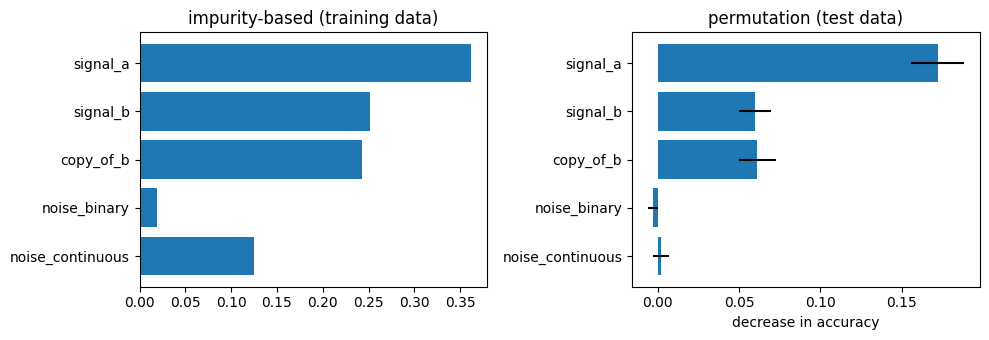

In [ ]:
# 不純度ベースの重要度とpermutation importanceを、偏りが出るように作ったデータで比べる
from sklearn.inspection import permutation_importance

rng = np.random.default_rng(0)
n = 3000
signal_a = rng.normal(size=n)
signal_b = rng.normal(size=n)
names = ["signal_a", "signal_b", "copy_of_b", "noise_binary", "noise_continuous"]
X = np.column_stack([
    signal_a,
    signal_b,
    signal_b + 0.05 * rng.normal(size=n),      # signal_bとほぼ同じ情報
    rng.integers(0, 2, size=n).astype(float),  # 無関係な2値
    rng.normal(size=n),                        # 無関係な連続値
])
# 目的変数はsignal_aとsignal_bだけで決まり、雑音が加わる
y = (signal_a + signal_b + rng.normal(scale=1.0, size=n) > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# 深さを制限しないランダムフォレスト（訓練データをほぼ完全に覚える）
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_train, y_train)
print("正解率 訓練 %.3f  テスト %.3f" % (rf.score(X_train, y_train), rf.score(X_test, y_test)))

# permutation importance: テストデータで各列を10回ずつ並べ替え、正解率の低下を平均する
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=0)

print("%-18s %10s %14s" % ("", "不純度ベース", "permutation"))
for i, name in enumerate(names):
    print("%-18s %10.3f %10.3f ± %.3f" % (name, rf.feature_importances_[i],
                                          perm.importances_mean[i], perm.importances_std[i]))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].barh(names, rf.feature_importances_)
ax[0].set_title("impurity-based (training data)")
ax[1].barh(names, perm.importances_mean, xerr=perm.importances_std)
ax[1].set_title("permutation (test data)")
ax[1].set_xlabel("decrease in accuracy")
for a in ax:
    a.invert_yaxis()
plt.tight_layout()
plt.show()

### 結果の読み方

2つの重要度で、評価が食い違う列に注目する

`noise_continuous` は目的変数と無関係であるのに、不純度ベースでは無視できない大きさの重要度が付く
- 同じく無関係な `noise_binary` は、ほぼ0である
- 2つの違いは値の種類の数だけであり、高カーディナリティの特徴量が過大評価されることがわかる
- permutation importanceでは、どちらもほぼ0となる
  - テストデータで並べ替えてもスコアが下がらない、つまり予測の役に立っていないことが正しく示される
- 訓練の正解率が1.0に近く、テストとの差が大きい点も合わせて見るとよい
  - 木が訓練データを覚え込むときに、無関係な連続値が分割の材料に使われている

`signal_b` と `copy_of_b` は、不純度ベースでは重要度を分け合い、それぞれ `signal_a` より小さくなる
- 実際には `signal_a` と `signal_b` は同じ強さで目的変数に効いている
- permutation importanceでも、この2列の値は `signal_a` より小さい
  - 片方を並べ替えても、モデルはもう片方から同じ情報を得られるため、スコアがあまり下がらない
- つまり、相関の強い特徴量については、**permutation importanceも当てにならない**
  - 対処としては、相関の強い列をまとめて1つだけ残してから測る、または、まとめて同時に並べ替える

重要度を読むときの注意をまとめる
- 不純度ベースの重要度は「訓練時に木がどの列を使ったか」であり、「未知のデータでどの列が役に立つか」ではない
- 特徴量を捨てる判断をする場合は、テストデータ（または検証用データ）でのpermutation importanceを併用する
- どちらの重要度も、モデルがその列を**使っている**度合いを示すだけであり、その列が結果の**原因**であることは示さない
- モデルの精度が低い場合、そのモデルの重要度を読んでも意味がないため、先に精度を確認する

## 深層学習やLLMではどう現れるか

深層学習では、特徴量を人が選ぶ代わりに、モデルが生のデータ（画素、波形、トークン）から表現を学習する
- そのため、列を選ぶという意味での特徴選択を行う場面は減る
- しかし、「モデルが何を使って予測しているかを、未知のデータで確かめる」という原則は、むしろ重要になる
  - 入力の次元が高く、モデルが何を手がかりにしているかが、表データよりも見えにくいためである

**近道を覚える**
- ニューラルネットワークは、訓練データの中でラベルと相関していれば、本来の手がかりでなくても利用する
  - 動物の種類を、動物そのものではなく背景（草原、雪）で見分ける
  - 医用画像の診断で、病変ではなく、撮影した施設や装置を示す画像の隅の文字を手がかりにする
- このような手がかりは、訓練データと同じ集め方をした評価データでも通用するため、成績は高く出る
  - 集め方の異なるデータに適用して初めて、成績が落ちることでわかる
- 上の実験で、無関係な連続値に木が重要度を与えたのと同じく、**訓練データの上で使えた**ことは、**役に立つ**ことを意味しない
- 前の節のグループのリークで、モデルが「この患者は誰か」を覚えたのも、近道の一種である

**入力を壊して、成績の変化を測る**
- permutation importance の考え方、すなわち「入力の一部を壊し、評価データでの成績がどれだけ下がるかを測る」は、モデルの種類を問わず使える
  - 画像の一部を隠す、文章から特定の語や段落を取り除く、入力の一部を別の標本のものと入れ替える
  - 背景だけを残した画像でも正解できるなら、モデルは背景を使っている
- 検索した文書を回答に使うシステムでは、検索結果を与えない場合と比べることで、検索が回答に寄与しているかを確かめられる
- ネットワークの一部（層、注意機構のヘッド）を取り除いて成績の変化を見る実験も、同じ考え方である

**可視化の読み方**
- 勾配や注意の重みから、入力のどこが効いたかを色で示す方法がある（「E-PyTorch-Advanced」の「説明可能AI」の節の SmoothGrad、Grad-CAM を参照）
- 重要度と同じく、これらが示すのはモデルがその部分を**使っている**度合いであり、その部分が結果の**原因**であることではない
- 相関の強い入力の間で重要度が分かれてしまう問題も、同じように起こる
- 精度の低いモデルの可視化を読んでも意味がないため、先に精度を確かめる

**入力を絞ることの意味**
- 入力を減らす利点（速度、費用、説明のしやすさ）は、深層学習でも変わらない
  - 画像の解像度、音声の長さ、LLMに渡す文脈の長さは、いずれも計算の費用に直結する
- LLMに渡す文脈に無関係な文書を多く入れると、費用が増えるだけでなく、回答の質が下がることがある
  - 無関係な特徴量が過学習の材料になるのと同じく、無関係な入力は誤りの材料になる

---

# まとめ（点検表）

本テキストの原則を、後編以降でモデルを学習させるたびに確かめる項目としてまとめる
- 使うライブラリが scikit-learn でも PyTorch でも、モデルが決定木でもLLMでも、同じ表が使える
- スコアが良すぎると感じたら、まずこの表の上から順に疑う

**分割**
- [ ] 運用時に新しくなるもの（時間、人、装置、文書）を単位として分けたか
- [ ] 同じ出所の標本（同じ話者、同じ患者、同じ文書のチャンク、同じ動画のフレーム）が、訓練側と評価側にまたがっていないか
- [ ] 時刻を持つデータで、評価側より未来の情報を学習に使っていないか
- [ ] 重複した標本、ほぼ重複した標本を、分割の前に調べたか
- [ ] データ拡張とサンプリングを、分割の後で訓練側にだけ行ったか
- [ ] 評価用のデータは、運用時のデータ（クラスの割合、撮影や録音の条件）を代表しているか

**前処理と特徴量**
- [ ] データから値を決める操作（正規化の平均と分散、補完値、語彙、選ぶ列、校正の変換）を、訓練データだけで行ったか
- [ ] 目的変数から作った特徴量に、その標本自身の正解が入っていないか
- [ ] 予測を行う時点で手に入らない情報を、入力に使っていないか
- [ ] 前処理に使う値（統計量、カテゴリの一覧、トークナイザ）を、モデルと組で保存したか
- [ ] 推論時に、モデルを推論用の状態に切り替えたか（PyTorch では `model.eval()`）

**候補の選び方**
- [ ] ハイパーパラメータ、学習を止める時点、しきい値、プロンプトを、検証データだけで選んだか
- [ ] テストデータで測ったのは、選び終えた後の1回だけか
- [ ] 事前学習済みのモデルを使う場合、評価用のデータが事前学習のデータに含まれている可能性を検討したか

**評価**
- [ ] 目的に合う指標を選んだか（不均衡データで正解率だけを見ていないか）
- [ ] 何も学習しない方法（常に多数派を答える、でたらめに答える）の値と比べたか
- [ ] 評価用のデータの件数、特に少数派の件数は、差を論じるのに足りているか
- [ ] 確率の値を使う場合、信頼性曲線またはECEで校正を確かめたか（重み付けやサンプリングを行った後は特に）

**判定と運用**
- [ ] 見逃しと誤検出の費用（または満たすべき制約）を、使う側と合意したか
- [ ] しきい値を、既定の0.5のままにせず、検証データで決めたか
- [ ] モデルが何を手がかりにしているかを、未知のデータで入力を壊して確かめたか
- [ ] 運用中に、陽性の割合や入力の分布が変わっていないかを見直す手順があるか

これらの項目に共通しているのは、次の3点である
- 評価用のデータは未知のデータの代役であり、**代役であり続けるように扱う**
- 数値は、**何と比べ、何のために測るのか**を決めて初めて意味を持つ
- 落とし穴に落ちてもエラーは出ないため、**注意ではなく手順で防ぐ**

---

# 課題1（データリークを再現し、手順で防ぐ）

`sklearn.datasets.load_breast_cancer` のデータ（569件、30特徴量）を用い、次の要件を満たすコードと考察を示せ

1. 全データに対して `StandardScaler` と `SelectKBest(f_classif, k=5)` を適用してから、`SVC` を5分割交差検証で評価せよ
2. 同じ処理を `Pipeline` にまとめ、同じ分割で評価せよ
3. 1と2の正解率の差を示し、本文の実験Bほど大きな差にならない理由を、件数、特徴量の数、特徴量と目的変数の関係の強さの観点から説明せよ
4. 次の加工をしたデータで1と2を再度実行し、正解率を多数派のクラスの割合と比べよ
   - `rng = np.random.default_rng(0)` を用い、569件から100件を無作為に取り出す
   - 乱数の列を2000列加える
   - 目的変数を `rng.permutation` で並べ替え、特徴量との関係を壊す
   - どちらの手順が多数派の割合を上回る値を返すかを示し、その理由を3の観点と合わせて説明せよ
5. 2の `Pipeline` を `GridSearchCV` に渡し、残す特徴量の数 `k` と `SVC` の `C` を同時に探索せよ
   - 最良の組み合わせと、そのときの交差検証の正解率を示せ
6. 5で得た正解率を、そのまま「未知のデータに対する性能」として報告してよいかを、本文の「テストデータで選ばない」の実験と関連づけて述べよ
   - よくない場合は、正しい評価の手順を示し、実際にその手順で得た値を5の値と比べよ
7. 画像を分類するニューラルネットワークを学習する場合に、1の誤りに相当する操作を2つ挙げ、それぞれをどう直すかを説明せよ

# 課題2（分割の単位を設計する）

次の手順で、同じ人から複数回測定したデータを作り、要件を満たすコードと考察を示せ
- 本文の「分割の仕方によるリーク：グループ」のコードを基に、患者200人、1人あたり測定5回、測定は患者ごとに時刻0〜4の順に行われたものとする
- 測定値には、時刻に比例してゆっくり増える成分を全項目に加える（係数は自分で決める）

1. 測定を単位とするランダムな分割、患者を単位とする分割（`GroupKFold`）のそれぞれで、ランダムフォレストの正解率を求めよ
2. 患者の半数を「新しい病院」の患者とし、その病院の測定値には全項目に一定の偏りを加えよ
   - 病院を単位とする分割（一方の病院で学習し、他方で評価する）の正解率を求め、1の2つの値と比べよ
3. 1と2の3つの正解率のうち、次の各場面で信用すべき値はどれかを、理由とともに述べよ
   - 同じ病院に来る新しい患者に使う
   - 別の病院に導入する
   - すでに登録されている患者の、次回の測定に使う
4. 1人あたりの測定回数を5回から20回に増やすと、1の2つの正解率の差はどう変わるかを実験し、理由を説明せよ
5. 次の3つの場面について、分割の単位を何にすべきかを、理由とともに述べよ
   - 複数の話者が読み上げた音声から、感情を認識するモデルを作る
   - 社内の文書をチャンクに分けて検索し、質問に回答するシステムを評価する
   - 毎日の売上から、翌週の売上を予測するモデルを作る

# 課題3（指標、校正、しきい値を一貫して決める）

次の手順で不均衡データを作り、要件を満たすコードと考察を示せ
- `make_classification(n_samples=20000, n_features=20, n_informative=6, weights=[0.98], flip_y=0.01, random_state=1)` を用いる
- 訓練用、検証用、テスト用に 6:2:2 で分割する
  - 分割には `stratify` を指定する

1. ロジスティック回帰とランダムフォレストを学習し、テストデータでの正解率、適合率、再現率、ROC-AUC、APを表にまとめよ
   - 常に多数派を答える方法の値も、同じ表に並べよ
2. 2つのモデルのPR曲線を1つの図に重ねて描け
   - でたらめに答えた場合の水準も線で示せ
3. 正解率だけを見た場合と、APを見た場合とで、2つのモデルの優劣の判断がどう変わるかを述べよ
4. 見逃し1件の費用を50、誤検出1件の費用を1とする
   - 検証用データを用いて費用の合計が最小になるしきい値をモデルごとに求め、テストデータでの費用を、しきい値0.5の場合と比較せよ
5. 2つのモデルの信頼性曲線を描け
   - 本文の式 $c_{FP}/(c_{FP}+c_{FN})$ から求めたしきい値と、4で求めたしきい値を比べ、差が大きいモデルについてその理由を説明せよ
6. ランダムフォレストの `feature_importances_` と、テストデータでの permutation importance を比べ、情報を持たない列（`make_classification` が末尾に加える乱数の列）がそれぞれでどう評価されるかを示せ
7. ここまでの手順のうち、検証用データで決めたものと、テストデータで測ったものを一覧にし、テストデータで決めたものが1つも無いことを確かめよ
8. 同じ問題をニューラルネットワークで解く場合に、4と5の手順のどこを、何に置き換えることになるかを説明せよ

# 参考文献

**データリークと分割**

- Kaufman, S. et al. (2012). "Leakage in Data Mining: Formulation, Detection, and Avoidance." ACM TKDD, 6(4)
- Micci-Barreca, D. (2001). "A Preprocessing Scheme for High-Cardinality Categorical Attributes in Classification and Prediction Problems." ACM SIGKDD Explorations, 3(1), 27-32
- Cawley, G. C. & Talbot, N. L. C. (2010). "On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation." JMLR, 11, 2079-2107
- scikit-learn. [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html)
- scikit-learn. [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)

**不均衡データ、校正、しきい値**

- Davis, J. & Goadrich, M. (2006). "The Relationship Between Precision-Recall and ROC Curves." ICML 2006
- Chawla, N. V. et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." JAIR, 16, 321-357
- Lin, T.-Y. et al. (2017). "Focal Loss for Dense Object Detection." ICCV 2017
- Niculescu-Mizil, A. & Caruana, R. (2005). "Predicting Good Probabilities with Supervised Learning." ICML 2005
- Guo, C. et al. (2017). "On Calibration of Modern Neural Networks." ICML 2017
- Elkan, C. (2001). "The Foundations of Cost-Sensitive Learning." IJCAI 2001
- scikit-learn. [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)

**特徴選択と重要度**

- Guyon, I. & Elisseeff, A. (2003). "An Introduction to Variable and Feature Selection." JMLR, 3, 1157-1182
- Strobl, C. et al. (2007). "Bias in random forest variable importance measures: Illustrations, sources and a solution." BMC Bioinformatics, 8, 25
- Geirhos, R. et al. (2020). "Shortcut Learning in Deep Neural Networks." Nature Machine Intelligence, 2, 665-673
- scikit-learn. [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

**ライブラリ**

- Pedregosa, F. et al. (2011). "scikit-learn: Machine Learning in Python." JMLR, 12, 2825-2830